# Description of this script

This Python script performs statistical analysis on quantum data (qubits and qutrits) and evaluates their anomaly detection performance. The main tasks include:

1. **Data loading**  
   - Loads `.npz` files containing qubit and qutrit measurement (mostly over 100 executions).  
   - Example datasets: `qubitsReal`, `qutritsReal`, `qutritsTau12E`, `qutritsd0dz`, etc. These files store all the results of the experiment after 100 runs.

2. **Statistical analysis**  
   - Computes **mean** and **median** fidelities for different processes/events:  
     - `HToBB`, `WToQQ`, `TTBar`, `back`  
   - Calculates **Jensen-Shannon Divergence (JSD)** between pairs of distributions to quantify differences.

3. **Anomaly detection metrics**  
   - Converts fidelities into anomaly scores: `anomaly_score = 1 - fidelity`.
   - Calculates **Area Under the ROC Curve (AUC)** for each event type against background.

4. **Aggregated metrics**  
   - Computes average AUC and JSD values over multiple trials (usually 100 iterations).  
   - Stores results for comparison across different quantum states and configurations.

5. **Visualization & summary**  
   - Prints mean and standard deviation of AUC values for each event type.  
   - Optionally, could generate ROC curves for visual evaluation (some imports suggest plotting is planned).

**Summary:**  
The script systematically analyzes qubit and qutrit fidelity data, quantifies distribution differences, and evaluates anomaly detection performance using ROC-AUC and Jensen-Shannon Divergence metrics.


---

---

⚠️ **Warning:**  This script was created for testing and quick calculations and not for the purpose of creating clean and efficient code. Optimisation of this script is planned for the future.

---
---

In [50]:
import numpy as np
from sklearn.metrics import roc_auc_score, roc_curve
from scipy.spatial.distance import jensenshannon
from scipy.stats import entropy
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import wasserstein_distance

In [197]:
import numpy as np

# 1. lt1
qubitsR_lt1 = np.load('./npz lt1/np_qubitsReal_lt1.npz', allow_pickle=True)
qutritsR_lt1 = np.load('./npz lt1/np_qutritsReal_lt1.npz', allow_pickle=True)
qubitsS_lt1 = np.load('./npz lt1/QubitsS_l1.npz', allow_pickle=True)
qutritsd0dz_lt1 = np.load('./npz lt1/np_qutrits_d0dz.npz', allow_pickle=True)
qutrits_tau12E_lt1 = np.load('./npz lt1/np_qutrits_tau12E.npz', allow_pickle=True)
qutrits_tau23E_lt1 = np.load('./npz lt1/np_qutrits_tau23E.npz', allow_pickle=True)
qutrits_tau34E_lt1 = np.load('./npz lt1/np_qutrits_tau34E.npz', allow_pickle=True)

# lt2
qubitsR_back = np.load('./npz back and 0/np_qubitsReal_back.npz', allow_pickle=True)
qutritsR_back = np.load('./npz back and 0/np_qutritsReal_back.npz', allow_pickle=True)
qubitsS_back = np.load('./npz back and 0/np_qubitsSimulado_back.npz', allow_pickle=True)
qutritsd0dz_back = np.load('./npz back and 0/np_qutrits_d0dz_back.npz', allow_pickle=True)
qutrits_tau12E_back = np.load('./npz back and 0/np_qutrits_tau12E_back.npz', allow_pickle=True)
qutrits_tau23E_back = np.load('./npz back and 0/np_qutrits_tau23E_back.npz', allow_pickle=True)
qutrits_tau34E_back = np.load('./npz back and 0/np_qutrits_tau34E_back.npz', allow_pickle=True)

# 3
qutrits_3_rand = np.load('./npz back and 0/np_qutrits_tau23E_3_rand.npz', allow_pickle=True)
qutrits_3_max = np.load('./npz back and 0/np_qutrits_tau23E_3_max.npz', allow_pickle=True)
qutrits_3_minus = np.load('./npz back and 0/np_qutrits_tau23E_3_minus.npz', allow_pickle=True)

#10
qubits10 = np.load('./npz back and 0/np_qubitsSimulado_10_lt2.npz', allow_pickle=True)


### **Auditoria de tamaños**

### **General functions**

In [198]:
def compute_wasserstein_runs2(signal_runs, background_runs):
    Ws = []

    for s in signal_runs:
        for b in background_runs:
            w = wasserstein_distance(s, b)
            Ws.append(w)

    return np.mean(Ws), np.std(Ws), np.array(Ws)

def compute_wasserstein_runs(signal_runs, background_runs):
    Ws = [wasserstein_distance(s, b) for s, b in zip(signal_runs, background_runs)]
    
    return np.mean(Ws), np.std(Ws), np.array(Ws)

def compute_tpr_vs_fpr(
    fpr_list,
    tpr_list,
    signal_label=r"$\text{Signal}$", # Nuevo parámetro para LaTeX
    dataset_label=r"$\text{Dataset}$", # Nuevo parámetro para LaTeX
    target_fprs=None,
    make_plot=False
):
    """
    Calcula TPR medio y std a varios FPR a partir de múltiples curvas ROC.
    Permite personalizar la leyenda con etiquetas LaTeX.
    """
    
    # Configuración opcional para que Matplotlib renderice LaTeX correctamente
    # plt.rcParams.update({"text.usetex": False, "font.family": "serif"})

    if target_fprs is None:
        # Valores típicos de FPR en escala logarítmica para HEP
        target_fprs = np.logspace(-4, 0, 50)

    results = {}

    for target in target_fprs:
        tpr_vals = [
            np.interp(target, fpr, tpr)
            for fpr, tpr in zip(fpr_list, tpr_list)
        ]

        results[target] = (
            np.mean(tpr_vals),
            np.std(tpr_vals)
        )

    # =========================
    # PRINT informativo
    # =========================
    print(f"\n=== TPR vs FPR para {signal_label} ===")
    # Solo imprimimos algunos puntos clave para no saturar la consola
    puntos_clave = [0.1, 0.01, 0.001]
    for target in puntos_clave:
        if target in results:
            m, s = results[target]
            print(f"FPR = {target:.7f} -> TPR = {m:.7f} ± {s}")

    # =========================
    # PLOT
    # =========================
    if make_plot:
        fprs = np.array(list(results.keys()))
        means = np.array([v[0] for v in results.values()])
        stds  = np.array([v[1] for v in results.values()])

        plt.figure(figsize=(7, 5))

        # Usamos la etiqueta LaTeX en el label del plot
        plt.plot(fprs, means, label=f"Mean TPR ({signal_label})", color='blue', lw=2)
        plt.fill_between(fprs, means - stds, means + stds, color='blue', alpha=0.2, label=r"$1\sigma$ band")

        plt.xscale("log")
        plt.xlabel("False Positive Rate (Background Acceptance)")
        plt.ylabel("True Positive Rate (Signal Efficiency)")
        plt.title(f"{signal_label} performance in {dataset_label}")
        
        plt.grid(True, which="both", ls="-", color='whitesmoke', alpha=0.5)
        plt.legend(loc="upper left")

        plt.show()

    return results


def get_tpr_stats(fpr_list, tpr_list, target_fprs=None):
    if target_fprs is None:
        target_fprs = np.logspace(-4, 0, 50)

    results = {}
    for target in target_fprs:
        tpr_vals = [np.interp(target, fpr, tpr) for fpr, tpr in zip(fpr_list, tpr_list)]
        results[target] = (np.mean(tpr_vals), np.std(tpr_vals))
    return results

def add_performance_curve(ax, fpr_list, tpr_list, label, color, target_fprs=None):
    """Calcula y añade una curva con su banda 1-sigma al eje 'ax' proporcionado"""
    stats = get_tpr_stats(fpr_list, tpr_list, target_fprs)
    
    fprs = np.array(list(stats.keys()))
    means = np.array([v[0] for v in stats.values()])
    stds  = np.array([v[1] for v in stats.values()])

    # Dibujamos la línea principal
    ax.plot(fprs, means, label=label, color=color, lw=0.8, zorder=3)
    
    # Dibujamos la banda 1-sigma (fondo blanco significa alpha bajo para no ensuciar)
    ax.fill_between(fprs, 
                    np.maximum(0, means - stds), 
                    np.minimum(1, means + stds), 
                    color=color, alpha=0.3, zorder=2, label=f"$1\sigma$ uncertainty")

### **Qubtits10**


In [200]:
qubitsR1_back_data = qubits10['fil_100_back_S'].squeeze()
qubitsR1_HToBB_data = qubits10['fil_100_HToBB_S'].squeeze()
qubitsR1_WToQQ_data = qubits10['fil_100_WToQQ_S'].squeeze()
qubitsR1_TTBar_data = qubits10['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qubitsR1_back_data.shape)
print(qubitsR1_HToBB_data.shape)
print(qubitsR1_WToQQ_data.shape)
print(qubitsR1_TTBar_data.shape)

(10, 10000)
(10, 10000)
(10, 10000)
(10, 10000)


In [201]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qubitsR1_WToQQ_data, qubitsR1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qubitsR1_TTBar_data, qubitsR1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qubitsR1_WToQQ_data, qubitsR1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.1488 ± 0.00449803524520531
WToQQ (Boson W) vs Background |     0.1010 ± 0.0045087286968890005
TTBar (Top) vs Background |     0.1828 ± 0.003764953753488269
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.0600 ± 0.0004875260407199331
HToBB (Higgs) vs TTBar (Top) |     0.0649 ± 0.0005033714294536259
WToQQ (Boson W) vs TTBar (Top) |     0.1201 ± 0.0009566299180814492
-------------------------------------------------------


In [202]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qubits10 = []
means_WToQQ_qubits10 = []
means_TTBar_qubits10 = []
means_back_qubits10 = []

median_HToBB_qubits10 = []
median_WToQQ_qubits10 = []
median_TTBar_qubits10 = []
median_back_qubits10 = []

auc_HToBB_list_qubits10 = []
auc_TTBar_list_qubits10 = []
auc_WToQQ_list_qubits10 = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0
# =========================
# Datos
# =========================


# =========================
# Loop sobre ejecuciones
# =========================

for i in range(10):


    # ---------- PDFs ----------
    pdf_back  = qubitsR1_back_data[i]
    pdf_HToBB = qubitsR1_HToBB_data[i]
    pdf_WToQQ = qubitsR1_WToQQ_data[i]
    pdf_TTBar = qubitsR1_TTBar_data[i]

    # ---------- JS divergence ----------
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB, pdf_back))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ, pdf_back))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar, pdf_back))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

     #----------- Valores estadísticos ----------

    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qubitsR1_back_data[i])
    anomaly_scores_HToBB = 1 - np.array(qubitsR1_HToBB_data[i])
    anomaly_scores_TTBar = 1 - np.array(qubitsR1_TTBar_data[i])
    anomaly_scores_WToQQ = 1 - np.array(qubitsR1_WToQQ_data[i])

    
    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qubits10.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qubits10.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qubits10.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)


fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar



# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qubits10)
std_auc_HToBB  = np.std(auc_HToBB_list_qubits10)
mean_auc_TTBar = np.mean(auc_TTBar_list_qubits10)
std_auc_TTBar  = np.std(auc_TTBar_list_qubits10)
mean_auc_WToQQ = np.mean(auc_WToQQ_list_qubits10)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qubits10)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== AUC (mean ± std) ===
HToBB  : 0.775124 ± 0.007481216927991414
WToQQ  : 0.721316 ± 0.008190951552917698
TTBar  : 0.863064 ± 0.004232896016447957
=== JS distance (mean ± std) ===
HToBB  : 0.006699 ± 0.00011976470055245376
WToQQ  : 0.006754 ± 0.00011147962560209944
TTBar  : 0.006166 ± 0.0001216831637887063
----------------------------------------------------------
HToBB  : 0.008098 ± 6.163000437472186e-05
HToBB  : 0.007616 ± 6.014866159895845e-05
WToQQ  : 0.007687 ± 5.985116483052248e-05


### **QUTRITS 0**

In [27]:
qutritsR_0 = np.load('./npz back and 0/np_qutritsReal_0.npz', allow_pickle=True)

qutritsR1_back_data = qutritsR_0['fil_100_back_S'].squeeze()
qutritsR1_HToBB_data = qutritsR_0['fil_100_HToBB_S'].squeeze()
qutritsR1_WToQQ_data = qutritsR_0['fil_100_WToQQ_S'].squeeze()
qutritsR1_TTBar_data = qutritsR_0['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsR1_back_data.shape)
print(qutritsR1_HToBB_data.shape)
print(qutritsR1_WToQQ_data.shape)
print(qutritsR1_TTBar_data.shape)

W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsR1_TTBar_data, qutritsR1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsReal = []
means_WToQQ_qutritsReal = []
means_TTBar_qutritsReal = []
means_back_qutritsReal = []

median_HToBB_qutritsReal = []
median_WToQQ_qutritsReal = []
median_TTBar_qutritsReal = []
median_back_qutritsReal = []

auc_HToBB_list_qutritsReal = []
auc_TTBar_list_qutritsReal = []
auc_WToQQ_list_qutritsReal = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- PDFs ----------
    pdf_back  = qutritsR1_back_data[i]
    pdf_HToBB = qutritsR1_HToBB_data[i]
    pdf_WToQQ = qutritsR1_WToQQ_data[i]
    pdf_TTBar = qutritsR1_TTBar_data[i]

    # ---------- JS divergence ----------
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB, pdf_back))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ, pdf_back))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar, pdf_back))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsR1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsR1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsR1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsR1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qutritsReal.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qutritsReal.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qutritsReal.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar


# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qutritsReal)
std_auc_HToBB  = np.std(auc_HToBB_list_qutritsReal)
mean_auc_TTBar = np.mean(auc_TTBar_list_qutritsReal)
std_auc_TTBar  = np.std(auc_TTBar_list_qutritsReal)
mean_auc_WToQQ = np.mean(auc_WToQQ_list_qutritsReal)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qutritsReal)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:.4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:.4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:.4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.7753 ± 0.04398099655211297
WToQQ (Boson W) vs Background |     0.2415 ± 0.03882378491116208
TTBar (Top) vs Background |     1.3615 ± 0.04410067832446212
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5593 ± 6.547202562256485e-05
HToBB (Higgs) vs TTBar (Top) |     0.5864 ± 6.728804058865753e-05
WToQQ (Boson W) vs TTBar (Top) |     1.1455 ± 0.00013138275367343026
-------------------------------------------------------
=== AUC (mean ± std) ===
HToBB  : 0.7037 ± 0.0024236543492677527
WToQQ  : 0.6676 ± 0.002509890097738535
TTBar  : 0.7890 ± 0.0021952863149025596
=== JS distance (mean ± std) ===
HToBB  : 0.042925 ± 0.0006149244753046271
WToQQ  : 0.035986 ± 0.00064531176086254
TTBar  : 0.046549 ± 0.0005460818377685575
----------

In [30]:
qutritsS_0 = np.load('./npz back and 0/np_qutrits_0.npz', allow_pickle=True)






qutritsR1_back_data = qutritsS_0['fil_100_back_S'].squeeze()
qutritsR1_HToBB_data = qutritsS_0['fil_100_HToBB_S'].squeeze()
qutritsR1_WToQQ_data = qutritsS_0['fil_100_WToQQ_S'].squeeze()
qutritsR1_TTBar_data = qutritsS_0['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsR1_back_data.shape)
print(qutritsR1_HToBB_data.shape)
print(qutritsR1_WToQQ_data.shape)
print(qutritsR1_TTBar_data.shape)

W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsR1_TTBar_data, qutritsR1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsReal = []
means_WToQQ_qutritsReal = []
means_TTBar_qutritsReal = []
means_back_qutritsReal = []

median_HToBB_qutritsReal = []
median_WToQQ_qutritsReal = []
median_TTBar_qutritsReal = []
median_back_qutritsReal = []

auc_HToBB_list_qutritsReal = []
auc_TTBar_list_qutritsReal = []
auc_WToQQ_list_qutritsReal = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- PDFs ----------
    pdf_back  = qutritsR1_back_data[i]
    pdf_HToBB = qutritsR1_HToBB_data[i]
    pdf_WToQQ = qutritsR1_WToQQ_data[i]
    pdf_TTBar = qutritsR1_TTBar_data[i]

    # ---------- JS divergence ----------
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB, pdf_back))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ, pdf_back))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar, pdf_back))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsR1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsR1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsR1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsR1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qutritsReal.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qutritsReal.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qutritsReal.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar


# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qutritsReal)
std_auc_HToBB  = np.std(auc_HToBB_list_qutritsReal)
mean_auc_TTBar = np.mean(auc_TTBar_list_qutritsReal)
std_auc_TTBar  = np.std(auc_TTBar_list_qutritsReal)
mean_auc_WToQQ = np.mean(auc_WToQQ_list_qutritsReal)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qutritsReal)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:.4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:.4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:.4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8654 ± 0.04424430225779966
WToQQ (Boson W) vs Background |     0.3111 ± 0.04189236589779481
TTBar (Top) vs Background |     1.4516 ± 0.04424186174081409
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5593 ± 2.4393373949648067e-05
HToBB (Higgs) vs TTBar (Top) |     0.5864 ± 3.731634998304755e-05
WToQQ (Boson W) vs TTBar (Top) |     1.1455 ± 6.163251668912224e-05
-------------------------------------------------------
=== AUC (mean ± std) ===
HToBB  : 0.7199 ± 0.0027648579829455365
WToQQ  : 0.6835 ± 0.0029048703135785238
TTBar  : 0.8051 ± 0.002358390840191373
=== JS distance (mean ± std) ===
HToBB  : 0.042378 ± 0.0005382105350117575
WToQQ  : 0.035351 ± 0.0006294076224136068
TTBar  : 0.046049 ± 0.0005410716650445504
--------

### **Qubit-based model** trained on real CMS data (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qubitsReal`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [ ]:
qubitsR1_back_data = qubitsR_lt1['fil_100_back_S'].squeeze()
qubitsR1_HToBB_data = qubitsR_lt1['fil_100_HToBB_S'].squeeze()
qubitsR1_WToQQ_data = qubitsR_lt1['fil_100_WToQQ_S'].squeeze()
qubitsR1_TTBar_data = qubitsR_lt1['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qubitsR1_back_data.shape)
print(qubitsR1_HToBB_data.shape)
print(qubitsR1_WToQQ_data.shape)
print(qubitsR1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [125]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qubitsR1_WToQQ_data, qubitsR1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qubitsR1_TTBar_data, qubitsR1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qubitsR1_HToBB_data, qubitsR1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qubitsR1_WToQQ_data, qubitsR1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.1469 ± 0.01361123458300906
WToQQ (Boson W) vs Background |     0.1179 ± 0.016315078665035388
TTBar (Top) vs Background |     0.2182 ± 0.010195142464865383
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.0798 ± 0.0005140604253191548
HToBB (Higgs) vs TTBar (Top) |     0.0845 ± 0.0008166469105244369
WToQQ (Boson W) vs TTBar (Top) |     0.1639 ± 0.001263157135631197
-------------------------------------------------------


In [126]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qubits10 = []
means_WToQQ_qubits10 = []
means_TTBar_qubits10 = []
means_back_qubits10 = []

median_HToBB_qubits10 = []
median_WToQQ_qubits10 = []
median_TTBar_qubits10 = []
median_back_qubits10 = []

auc_HToBB_list_qubits10 = []
auc_TTBar_list_qubits10 = []
auc_WToQQ_list_qubits10 = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0
# =========================
# Datos
# =========================


# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- PDFs ----------
    pdf_back  = qubitsR1_back_data[i]
    pdf_HToBB = qubitsR1_HToBB_data[i]
    pdf_WToQQ = qubitsR1_WToQQ_data[i]
    pdf_TTBar = qubitsR1_TTBar_data[i]

    # ---------- JS divergence ----------
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB, pdf_back))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ, pdf_back))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar, pdf_back))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

     #----------- Valores estadísticos ----------

    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qubitsR1_back_data[i])
    anomaly_scores_HToBB = 1 - np.array(qubitsR1_HToBB_data[i])
    anomaly_scores_TTBar = 1 - np.array(qubitsR1_TTBar_data[i])
    anomaly_scores_WToQQ = 1 - np.array(qubitsR1_WToQQ_data[i])

    
    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qubits10.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qubits10.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qubits10.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)


fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar



# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qubits10)
std_auc_HToBB  = np.std(auc_HToBB_list_qubits10)
mean_auc_TTBar = np.mean(auc_TTBar_list_qubits10)
std_auc_TTBar  = np.std(auc_TTBar_list_qubits10)
mean_auc_WToQQ = np.mean(auc_WToQQ_list_qubits10)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qubits10)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== AUC (mean ± std) ===
HToBB  : 0.732673 ± 0.03781178554602222
WToQQ  : 0.691876 ± 0.03293083995315759
TTBar  : 0.807372 ± 0.039926248241075026
=== JS distance (mean ± std) ===
HToBB  : 0.012228 ± 0.00041781898819545475
WToQQ  : 0.013357 ± 0.000390270202620043
TTBar  : 0.011837 ± 0.000428440526386409
----------------------------------------------------------
HToBB  : 0.014348 ± 8.946043161981968e-05
HToBB  : 0.012922 ± 0.00010467933506361114
WToQQ  : 0.014024 ± 9.340355473303165e-05


In [127]:
    

# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qubits10) + 
                   np.array(auc_WToQQ_list_qubits10) + 
                   np.array(auc_TTBar_list_qubits10)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qubits10[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qubits10[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qubits10[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 0) ===
AUC HToBB: 0.7499
AUC WToQQ: 0.7082
AUC TTBar: 0.8237


In [62]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 991639
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    99.1639%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 981534
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.1534%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 986361
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.6361%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 976526
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.6526%
------------------------------


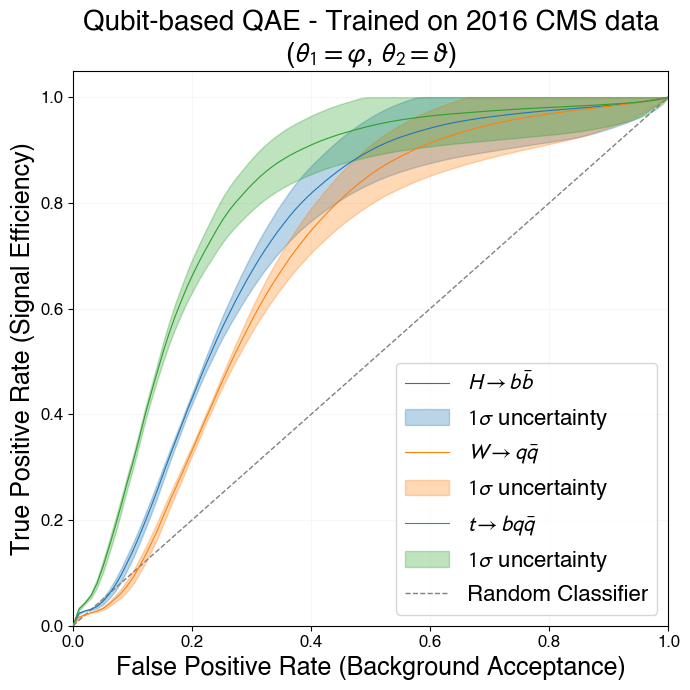

In [131]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})


fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)


ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=18, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=18, fontname="Helvetica")
ax.set_title(r"Qubit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$)", fontsize=20, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.savefig(f"qubitR_ROC.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

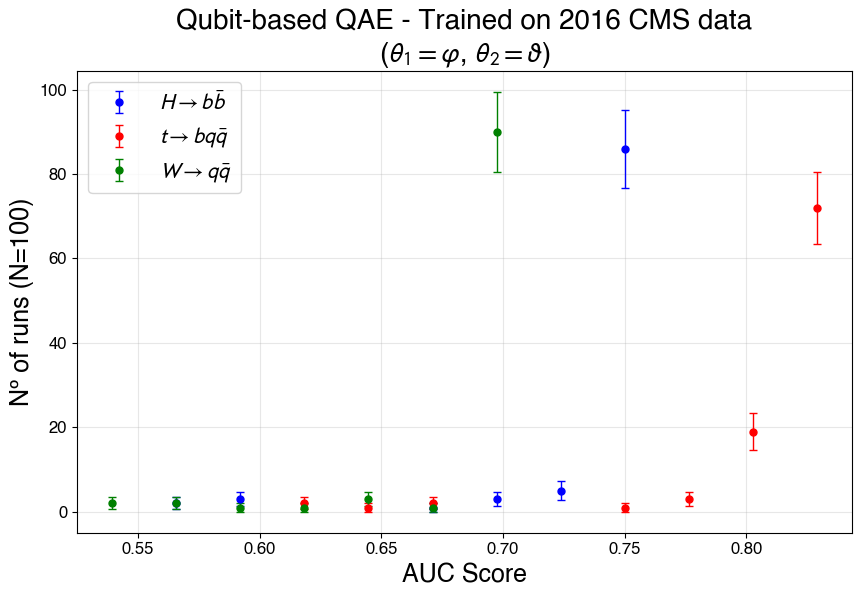

In [130]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qubits10,
    'TTBar': auc_TTBar_list_qubits10,
    'WToQQ': auc_WToQQ_list_qubits10
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qubit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$)" , fontsize=20, fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=18, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=18, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.grid(alpha=0.3)
plt.savefig(f"qubitR_AUC.pdf", bbox_inches='tight')
plt.show()

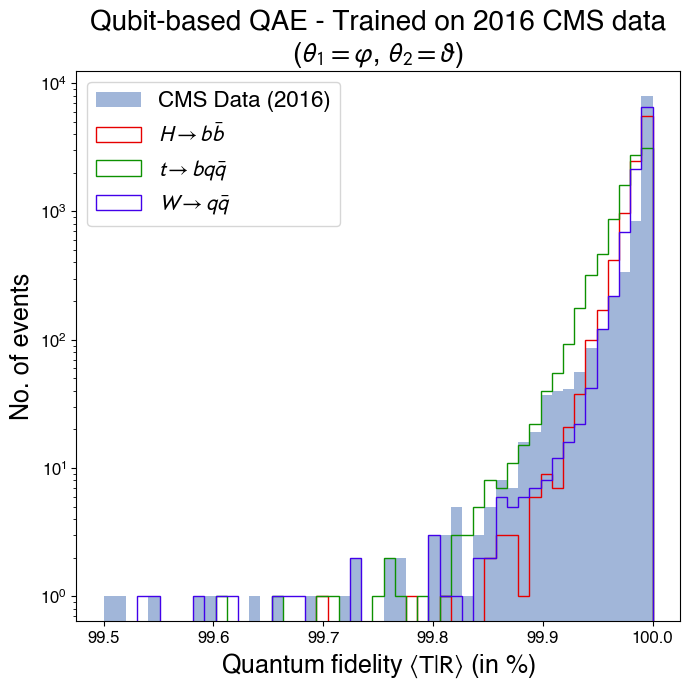

In [135]:
qubitsR1_back_data = qubitsR_lt1['fil_100_back_S'].squeeze()
qubitsR1_HToBB_data = qubitsR_lt1['fil_100_HToBB_S'].squeeze()
qubitsR1_WToQQ_data = qubitsR_lt1['fil_100_WToQQ_S'].squeeze()
qubitsR1_TTBar_data = qubitsR_lt1['fil_100_TTBar_S'].squeeze()


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(99.5, 100, 50)

# Background: blue fill
plt.hist(qubitsR1_back_data[0].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'CMS Data (2016)')

#  H → bb : 
plt.hist(qubitsR1_HToBB_data[0].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qubitsR1_TTBar_data[0].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qubitsR1_WToQQ_data[0].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=18)
plt.ylabel(r'No. of events', fontsize=18)
plt.title(r"Qubit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$)" , fontsize=20, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.tight_layout()
plt.savefig(f"qubitR_99.pdf", bbox_inches='tight')
plt.show()

### **ANALIZAMOS BACK-BACK**

In [12]:
qubitsR_back_data = qubitsR_back['fil_100_back_S'].squeeze()
qubitsR_back2_data = qubitsR_back['fil_100_back2_S'].squeeze()

# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qubitsR_back_data.shape)
print(qubitsR_back2_data.shape)

W_back_mean, W_back_std, W_back_all = compute_wasserstein_runs(qubitsR_back_data, qubitsR_back2_data)

print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("Background vs Background", W_back_mean, W_back_std),
]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_back_list = []
jsd_back = []
fpr_back_list = []
tpr_back_list = []


for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qubitsR_back_data[i]
    pdf_back2 = qubitsR_back2_data[i]
    # ---------- JS divergence ----------
    jsd_back.append(jensenshannon(pdf_back2, pdf_back))
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qubitsR_back_data[i])
    anomaly_scores_back2 = 1 - np.array(qubitsR_back2_data[i])


    y_true_back = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_back2)
    ])

    scores_back = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_back2
    ])

    fpr_back, tpr_back, _ = roc_curve(y_true_back, scores_back)
    auc_back = roc_auc_score(y_true_back, scores_back)

    auc_back_list.append(auc_back)
    fpr_back_list.append(fpr_back)
    tpr_back_list.append(tpr_back)

# =========================
mean_auc_back = np.mean(auc_back_list)
std_auc_back  = np.std(auc_back_list)

mean_jsd_back = np.mean(jsd_back)
std_jsd_back  = np.std(jsd_back)

print("=== AUC (mean ± std) ===")
print(f"Back  : {mean_auc_back:4f} ± {std_auc_back}")

print("=== JS distance (mean ± std) ===")
print(f"Back  : {mean_jsd_back:4f} ± {std_jsd_back}")


(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
Background vs Background  |     0.0287 ± 0.013640687101051237
-------------------------------------------------------
=== AUC (mean ± std) ===
Back  : 0.499789 ± 0.004722771324807424
=== JS distance (mean ± std) ===
Back  : 0.011487 ± 0.0006435512372892745


### **Qutrit-based** model trained on real CMS data (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsReal`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [136]:
qutritsR1_back_data = qutritsR_lt1['fil_100_back_S'].squeeze()
qutritsR1_HToBB_data = qutritsR_lt1['fil_100_HToBB_S'].squeeze()
qutritsR1_WToQQ_data = qutritsR_lt1['fil_100_WToQQ_S'].squeeze()
qutritsR1_TTBar_data = qutritsR_lt1['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsR1_back_data.shape)
print(qutritsR1_HToBB_data.shape)
print(qutritsR1_WToQQ_data.shape)
print(qutritsR1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [137]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsR1_TTBar_data, qutritsR1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsR1_HToBB_data, qutritsR1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsR1_WToQQ_data, qutritsR1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.7756 ± 0.04378573390225445
WToQQ (Boson W) vs Background |     0.2415 ± 0.038778096288468095
TTBar (Top) vs Background |     1.3616 ± 0.043856188942728254
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5596 ± 0.0001962588379454107
HToBB (Higgs) vs TTBar (Top) |     0.5863 ± 0.0003664958298175244
WToQQ (Boson W) vs TTBar (Top) |     1.1457 ± 0.0005649802357756977
-------------------------------------------------------


In [138]:

# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsReal = []
means_WToQQ_qutritsReal = []
means_TTBar_qutritsReal = []
means_back_qutritsReal = []

median_HToBB_qutritsReal = []
median_WToQQ_qutritsReal = []
median_TTBar_qutritsReal = []
median_back_qutritsReal = []

auc_HToBB_list_qutritsReal = []
auc_TTBar_list_qutritsReal = []
auc_WToQQ_list_qutritsReal = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- PDFs ----------
    pdf_back  = qutritsR1_back_data[i]
    pdf_HToBB = qutritsR1_HToBB_data[i]
    pdf_WToQQ = qutritsR1_WToQQ_data[i]
    pdf_TTBar = qutritsR1_TTBar_data[i]

    # ---------- JS divergence ----------
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB, pdf_back))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ, pdf_back))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar, pdf_back))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsR1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsR1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsR1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsR1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qutritsReal.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qutritsReal.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qutritsReal.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar


# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qutritsReal)
std_auc_HToBB  = np.std(auc_HToBB_list_qutritsReal)
mean_auc_TTBar = np.mean(auc_TTBar_list_qutritsReal)
std_auc_TTBar  = np.std(auc_TTBar_list_qutritsReal)
mean_auc_WToQQ = np.mean(auc_WToQQ_list_qutritsReal)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qutritsReal)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:.4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:.4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:.4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== AUC (mean ± std) ===
HToBB  : 0.7113 ± 0.0028614038848409746
WToQQ  : 0.6686 ± 0.0029738928786746414
TTBar  : 0.7909 ± 0.0025786859586482127
=== JS distance (mean ± std) ===
HToBB  : 0.042922 ± 0.0006179040942229113
WToQQ  : 0.035983 ± 0.0006480758183173505
TTBar  : 0.046545 ± 0.0005493909586320863
----------------------------------------------------------
HToBB  : 0.044514 ± 1.1636795701220535e-05
HToBB  : 0.053341 ± 1.3338081391343614e-05
WToQQ  : 0.048715 ± 1.2963754268814573e-05


In [153]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 981700
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.1700%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 972599
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.2599%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 980795
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.0795%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 960380
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    96.0380%
------------------------------


In [139]:


# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qutritsReal) + 
                   np.array(auc_WToQQ_list_qutritsReal) + 
                   np.array(auc_TTBar_list_qutritsReal)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qutritsReal[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qutritsReal[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qutritsReal[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 85) ===
AUC HToBB: 0.7177
AUC WToQQ: 0.6750
AUC TTBar: 0.7965


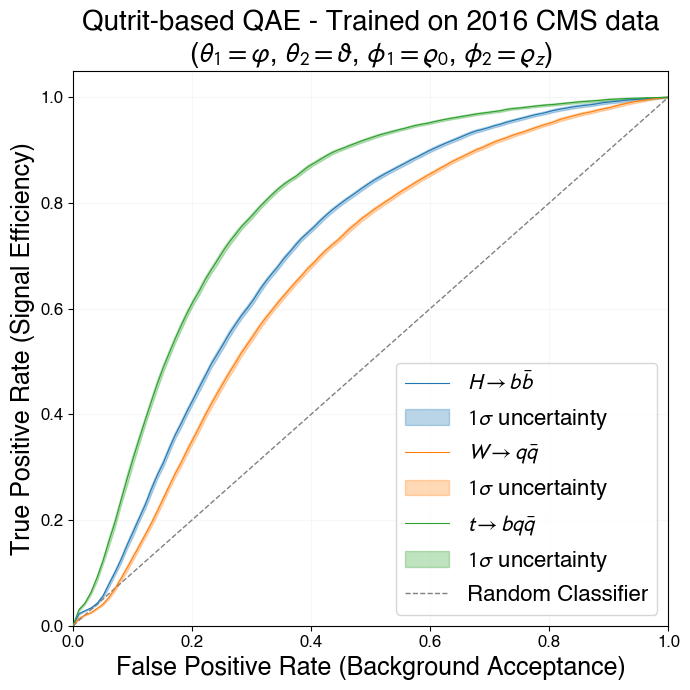

In [140]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=18, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=18, fontname="Helvetica")
ax.set_title(r"Qutrit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=20, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.savefig(f"qutritsR_ROC.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

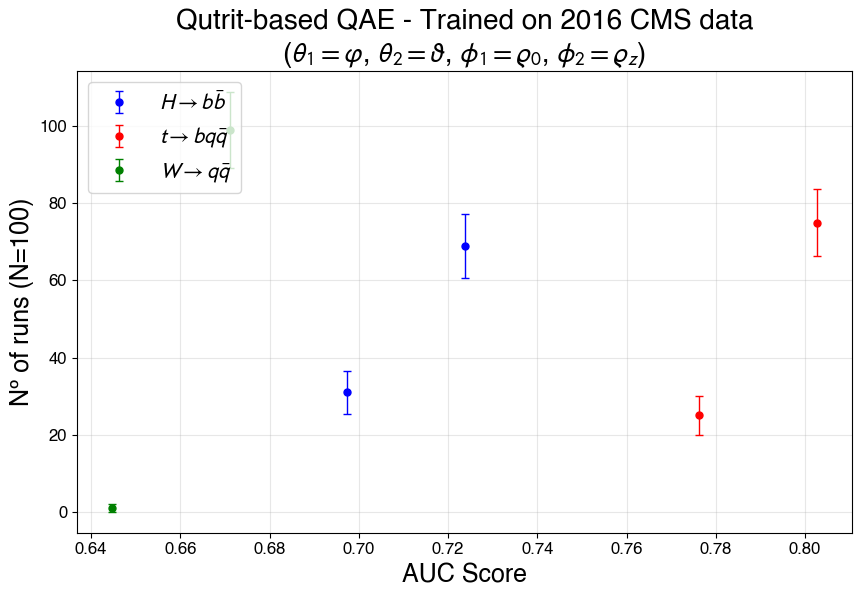

In [141]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qutritsReal,
    'TTBar': auc_TTBar_list_qutritsReal,
    'WToQQ': auc_WToQQ_list_qutritsReal
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qutrit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=18, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=18, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.grid(alpha=0.3)
plt.savefig(f"qutritsR_AUC.pdf", bbox_inches='tight')
plt.show()

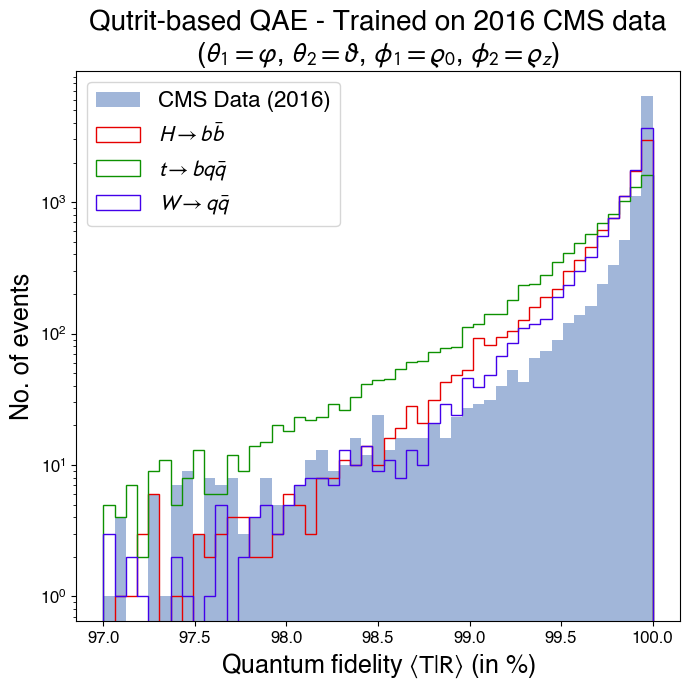

In [143]:
qutritsR1_back_data = qutritsR_lt1['fil_100_back_S'].squeeze()
qutritsR1_HToBB_data = qutritsR_lt1['fil_100_HToBB_S'].squeeze()
qutritsR1_WToQQ_data = qutritsR_lt1['fil_100_WToQQ_S'].squeeze()
qutritsR1_TTBar_data = qutritsR_lt1['fil_100_TTBar_S'].squeeze()


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsR1_back_data[85].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'CMS Data (2016)')

#  H → bb : 
plt.hist(qutritsR1_HToBB_data[85].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsR1_TTBar_data[85].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsR1_WToQQ_data[85].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=18)
plt.ylabel(r'No. of events', fontsize=18)

plt.title(r"Qutrit-based QAE - Trained on 2016 CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.tight_layout()
plt.savefig(f"qutritsR_97.pdf", bbox_inches='tight')
plt.show()

### **ANALIZAMOS BACK-BACK**

In [26]:
qutritsR_back_data = qutritsR_back['fil_100_back_S'].squeeze()
qutritsR_back2_data = qutritsR_back['fil_100_back2_S'].squeeze()

# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qubitsR_back_data.shape)
print(qubitsR_back2_data.shape)

W_back_mean, W_back_std, W_back_all = compute_wasserstein_runs(qutritsR_back_data, qutritsR_back2_data)

print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("Background vs Background", W_back_mean, W_back_std),
]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_back_list = []
jsd_back = []
fpr_back_list = []
tpr_back_list = []


for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutritsR_back_data[i]
    pdf_back2 = qutritsR_back2_data[i]
    # ---------- JS divergence ----------
    jsd_back.append(jensenshannon(pdf_back2, pdf_back))
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qutritsR_back_data[i])
    anomaly_scores_back2 = 1 - np.array(qutritsR_back2_data[i])


    y_true_back = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_back2)
    ])

    scores_back = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_back2
    ])

    fpr_back, tpr_back, _ = roc_curve(y_true_back, scores_back)
    auc_back = roc_auc_score(y_true_back, scores_back)

    auc_back_list.append(auc_back)
    fpr_back_list.append(fpr_back)
    tpr_back_list.append(tpr_back)

# =========================
mean_auc_back = np.mean(auc_back_list)
std_auc_back  = np.std(auc_back_list)

mean_jsd_back = np.mean(jsd_back)
std_jsd_back  = np.std(jsd_back)

print("=== AUC (mean ± std) ===")
print(f"Back  : {mean_auc_back:4f} ± {std_auc_back}")

print("=== JS distance (mean ± std) ===")
print(f"Back  : {mean_jsd_back:4f} ± {std_jsd_back}")


(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
Background vs Background  |     0.0746 ± 0.04578998702543082
-------------------------------------------------------
=== AUC (mean ± std) ===
Back  : 0.499768 ± 0.004575768597005038
=== JS distance (mean ± std) ===
Back  : 0.034824 ± 0.0009712452084880389


### **Qubit-based** model trained on simulated CMS data (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qubits`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [144]:
qubitsS1_back_data  = qubitsS_lt1['fil_100_back_S'].squeeze()
qubitsS1_HToBB_data = qubitsS_lt1['fil_100_HToBB_S'].squeeze()
qubitsS1_WToQQ_data = qubitsS_lt1['fil_100_WToQQ_S'].squeeze()
qubitsS1_TTBar_data = qubitsS_lt1['fil_100_TTBar_S'].squeeze()

print(qubitsS1_back_data.shape)
print(qubitsS1_HToBB_data.shape)
print(qubitsS1_WToQQ_data.shape)
print(qubitsS1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [145]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qubitsS1_HToBB_data, qubitsS1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qubitsS1_WToQQ_data, qubitsS1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qubitsS1_TTBar_data, qubitsS1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qubitsS1_HToBB_data, qubitsS1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qubitsS1_HToBB_data, qubitsS1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qubitsS1_WToQQ_data, qubitsS1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.1645 ± 0.013821980467650508
WToQQ (Boson W) vs Background |     0.1401 ± 0.015019892080794392
TTBar (Top) vs Background |     0.2273 ± 0.010642511389332593
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.0797 ± 0.0004499494677602076
HToBB (Higgs) vs TTBar (Top) |     0.0845 ± 0.0007137638962389197
WToQQ (Boson W) vs TTBar (Top) |     0.1638 ± 0.0011320536269076064
-------------------------------------------------------


In [146]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qubits = []
means_WToQQ_qubits = []
means_TTBar_qubits = []
means_back_qubits = []

median_HToBB_qubits = []
median_WToQQ_qubits = []
median_TTBar_qubits = []
median_back_qubits = []

auc_HToBB_list_qubits = []
auc_TTBar_list_qubits = []
auc_WToQQ_list_qubits = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):


    # ---------- Stats ----------


    # ---------- PDFs ----------
    pdf_back  = qubitsS1_back_data[i]
    pdf_HToBB = qubitsS1_HToBB_data[i]
    pdf_WToQQ = qubitsS1_WToQQ_data[i]
    pdf_TTBar = qubitsS1_TTBar_data[i]

    # ---------- JS divergence ----------
    len_h_b = min(len(pdf_HToBB), len(pdf_back))
    len_w_b = min(len(pdf_WToQQ), len(pdf_back))
    len_t_b = min(len(pdf_TTBar), len(pdf_back))

    # 2. Aplicamos el recorte [:min_len] directamente en la función
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:len_h_b], pdf_back[:len_h_b]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:len_w_b], pdf_back[:len_w_b]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:len_t_b], pdf_back[:len_t_b]))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))


    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qubitsS1_back_data[i]
    anomaly_scores_HToBB = 1 - qubitsS1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qubitsS1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qubitsS1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_HToBB)
    ])

    scores_HToBB = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_HToBB
    ])

    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)

    auc_HToBB_list_qubits.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_TTBar)
    ])

    scores_TTBar = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_TTBar
    ])

    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    auc_TTBar_list_qubits.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_WToQQ)
    ])

    scores_WToQQ = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_WToQQ
    ])

    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ_list_qubits.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Promedios AUC
# =========================

mean_auc_HToBB = np.mean(auc_HToBB_list_qubits)
std_auc_HToBB  = np.std(auc_HToBB_list_qubits)

mean_auc_TTBar = np.mean(auc_TTBar_list_qubits)
std_auc_TTBar  = np.std(auc_TTBar_list_qubits)

mean_auc_WToQQ = np.mean(auc_WToQQ_list_qubits)
std_auc_WToQQ  = np.std(auc_WToQQ_list_qubits)

print("=== AUC (mean ± std) ===")
print(f"HToBB  : {mean_auc_HToBB:.4f} ± {std_auc_HToBB}")
print(f"WToQQ  : {mean_auc_WToQQ:.4f} ± {std_auc_WToQQ}")
print(f"TTBar  : {mean_auc_TTBar:.4f} ± {std_auc_TTBar}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}") 

=== AUC (mean ± std) ===
HToBB  : 0.7563 ± 0.02852052436958618
WToQQ  : 0.7144 ± 0.025701878282431884
TTBar  : 0.8295 ± 0.027649997819311316
=== JS distance (mean ± std) ===
HToBB  : 0.011629 ± 0.00039653035170163334
WToQQ  : 0.012805 ± 0.00035927372743200966
TTBar  : 0.011207 ± 0.0004133697927758977
----------------------------------------------------------
HToBB  : 0.014346 ± 8.166146280203932e-05
HToBB  : 0.012919 ± 9.791564480903123e-05
WToQQ  : 0.014022 ± 8.634356139499612e-05


In [44]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 992097
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    99.2097%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 981570
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.1570%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 986376
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.6376%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 976559
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.6559%
------------------------------


In [147]:


# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qubits) + 
                   np.array(auc_WToQQ_list_qubits) + 
                   np.array(auc_TTBar_list_qubits)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qubits[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qubits[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qubits[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 34) ===
AUC HToBB: 0.7715
AUC WToQQ: 0.7297
AUC TTBar: 0.8426


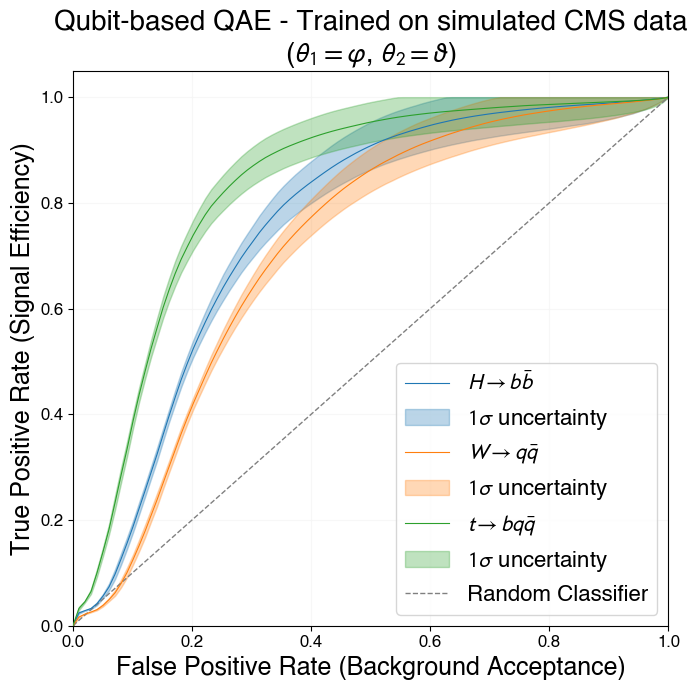

In [148]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=18, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=18, fontname="Helvetica")
ax.set_title(r"Qubit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$)", fontsize=20, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.savefig(f"qubitsS_ROC.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

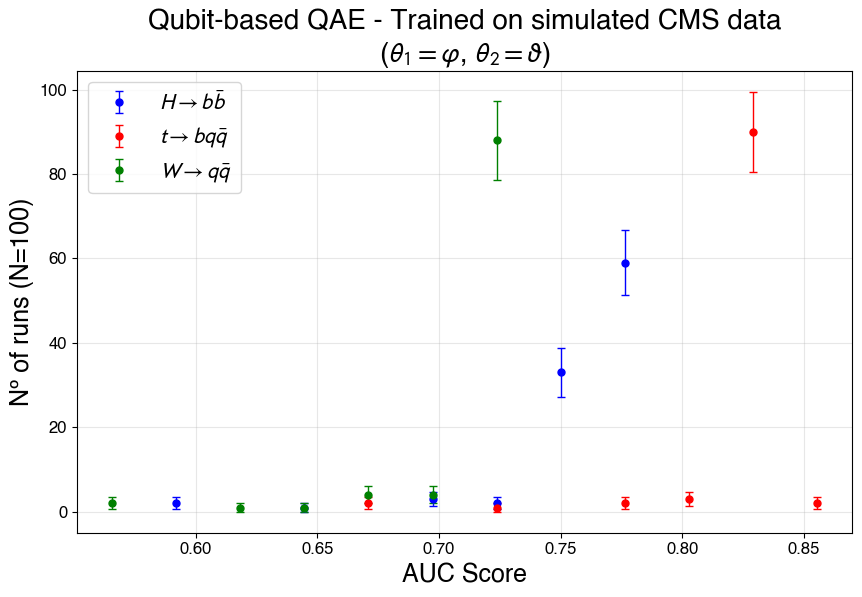

In [149]:
import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qubits,
    'TTBar': auc_TTBar_list_qubits,
    'WToQQ': auc_WToQQ_list_qubits
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qubit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$)" , fontsize=20, fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=18, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=18, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.grid(alpha=0.3)
plt.savefig(f"qubitsS_AUC.pdf", bbox_inches='tight')
plt.show()

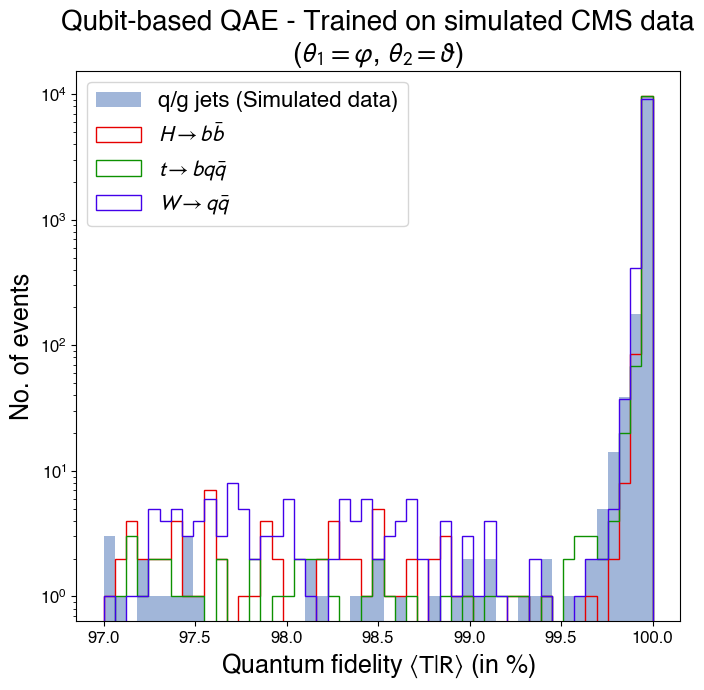

In [151]:
qubitsS1_back_data  = qubitsS_lt1['fil_100_back_S'].squeeze()
qubitsS1_HToBB_data = qubitsS_lt1['fil_100_HToBB_S'].squeeze()
qubitsS1_WToQQ_data = qubitsS_lt1['fil_100_WToQQ_S'].squeeze()
qubitsS1_TTBar_data = qubitsS_lt1['fil_100_TTBar_S'].squeeze()


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qubitsS1_back_data[34].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qubitsS1_HToBB_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qubitsS1_WToQQ_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qubitsS1_TTBar_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=18)
plt.ylabel(r'No. of events', fontsize=18)
plt.title(r"Qubit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$)" , fontsize=20, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.tight_layout()
plt.savefig(f"qubitsS_97.pdf", bbox_inches='tight')
plt.show()

### **ANALIZAMOS BACK-BACK**

In [36]:
qubitsS_back_data = qubitsS_back['fil_100_back_S'].squeeze()
qubitsS_back2_data = qubitsS_back['fil_100_back_S_2'].squeeze()

# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qubitsR_back_data.shape)
print(qubitsR_back2_data.shape)

W_back_mean, W_back_std, W_back_all = compute_wasserstein_runs(qubitsR_back_data, qubitsR_back2_data)

print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("Background vs Background", W_back_mean, W_back_std),
]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_back_list = []
jsd_back = []
fpr_back_list = []
tpr_back_list = []


for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qubitsS_back_data[i]
    pdf_back2 = qubitsS_back2_data[i]
    # ---------- JS divergence ----------
    jsd_back.append(jensenshannon(pdf_back2, pdf_back))
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qubitsS_back_data[i])
    anomaly_scores_back2 = 1 - np.array(qubitsS_back2_data[i])


    y_true_back = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_back2)
    ])

    scores_back = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_back2
    ])

    fpr_back, tpr_back, _ = roc_curve(y_true_back, scores_back)
    auc_back = roc_auc_score(y_true_back, scores_back)

    auc_back_list.append(auc_back)
    fpr_back_list.append(fpr_back)
    tpr_back_list.append(tpr_back)

# =========================
mean_auc_back = np.mean(auc_back_list)
std_auc_back  = np.std(auc_back_list)

mean_jsd_back = np.mean(jsd_back)
std_jsd_back  = np.std(jsd_back)

print("=== AUC (mean ± std) ===")
print(f"Back  : {mean_auc_back:4f} ± {std_auc_back}")

print("=== JS distance (mean ± std) ===")
print(f"Back  : {mean_jsd_back:4f} ± {std_jsd_back}")


(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
Background vs Background  |     0.0287 ± 0.013640687101051237
-------------------------------------------------------
=== AUC (mean ± std) ===
Back  : 0.499569 ± 0.004067660052951982
=== JS distance (mean ± std) ===
Back  : 0.009819 ± 0.0006877887746687252


### **Qutrits-based** model trained on simulated CMS data and using the **longitudinal and trasversal impact parameters** [d0, dz] (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsd0dz`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [152]:
qutritsS1_d0dz_back_data  = qutritsd0dz_lt1['fil_100_back_S'].squeeze()
qutritsS1_d0dz_HToBB_data = qutritsd0dz_lt1['fil_100_HToBB_S'].squeeze()
qutritsS1_d0dz_WToQQ_data = qutritsd0dz_lt1['fil_100_WToQQ_S'].squeeze()
qutritsS1_d0dz_TTBar_data = qutritsd0dz_lt1['fil_100_TTBar_S'].squeeze()

print(qutritsS1_d0dz_back_data.shape)
print(qutritsS1_d0dz_HToBB_data.shape)
print(qutritsS1_d0dz_WToQQ_data.shape)
print(qutritsS1_d0dz_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [153]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsS1_d0dz_HToBB_data, qutritsS1_d0dz_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsS1_d0dz_WToQQ_data, qutritsS1_d0dz_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsS1_d0dz_TTBar_data, qutritsS1_d0dz_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsS1_d0dz_HToBB_data, qutritsS1_d0dz_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsS1_d0dz_HToBB_data, qutritsS1_d0dz_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsS1_d0dz_WToQQ_data, qutritsS1_d0dz_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8657 ± 0.04416447914288313
WToQQ (Boson W) vs Background |     0.3110 ± 0.0418490301304558
TTBar (Top) vs Background |     1.4518 ± 0.0441171582627457
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5596 ± 0.0002723876030706097
HToBB (Higgs) vs TTBar (Top) |     0.5863 ± 0.0003021925180860825
WToQQ (Boson W) vs TTBar (Top) |     1.1458 ± 0.0005762403312643583
-------------------------------------------------------


In [154]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsd0dz = []
means_WToQQ_qutritsd0dz = []
means_TTBar_qutritsd0dz = []
means_back_qutritsd0dz = []

median_HToBB_qutritsd0dz = []
median_WToQQ_qutritsd0dz = []
median_TTBar_qutritsd0dz = []
median_back_qutritsd0dz = []

auc_HToBB_list_qutritsd0dz = []
auc_TTBar_list_qutritsd0dz = []
auc_WToQQ_list_qutritsd0dz = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutritsS1_d0dz_back_data[i]
    pdf_HToBB = qutritsS1_d0dz_HToBB_data[i]
    pdf_WToQQ = qutritsS1_d0dz_WToQQ_data[i]
    pdf_TTBar = qutritsS1_d0dz_TTBar_data[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales (también con recorte por seguridad)
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsS1_d0dz_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsS1_d0dz_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsS1_d0dz_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsS1_d0dz_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsd0dz.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsd0dz.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsd0dz.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Promedios finales
# =========================

print("=== Resultados qutritsd0dz ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsd0dz):.4f} ± {np.std(auc_HToBB_list_qutritsd0dz)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsd0dz):.4f} ± {np.std(auc_WToQQ_list_qutritsd0dz)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsd0dz):.4f} ± {np.std(auc_TTBar_list_qutritsd0dz)}")

# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== Resultados qutritsd0dz ===
AUC HToBB: 0.7278 ± 0.0035065696974270508
AUC WToQQ: 0.6844 ± 0.003531473115665436
AUC TTBar: 0.8070 ± 0.0032369152782796423
=== JS distance (mean ± std) ===
HToBB  : 0.042377 ± 0.0005392385391167567
WToQQ  : 0.035350 ± 0.0006299951908879592
TTBar  : 0.046047 ± 0.000542617820191426
----------------------------------------------------------
HToBB  : 0.044516 ± 9.157192528205854e-06
HToBB  : 0.053343 ± 1.0728637297515188e-05
WToQQ  : 0.048717 ± 9.881003834215178e-06


In [155]:


# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qutritsd0dz) + 
                   np.array(auc_WToQQ_list_qutritsd0dz) + 
                   np.array(auc_TTBar_list_qutritsd0dz)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qutritsd0dz[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qutritsd0dz[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qutritsd0dz[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 34) ===
AUC HToBB: 0.7344
AUC WToQQ: 0.6912
AUC TTBar: 0.8127


In [17]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 984996
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.4996%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 972597
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.2597%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 980797
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.0797%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 960387
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    96.0387%
------------------------------


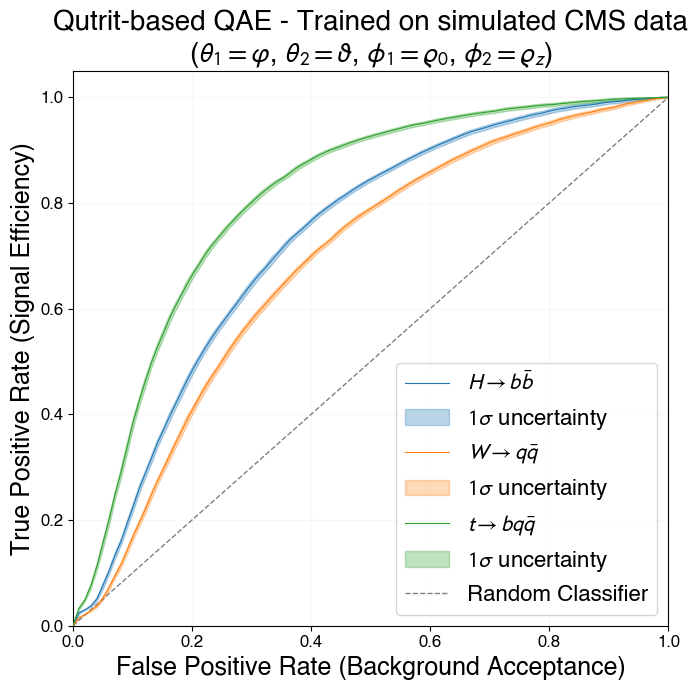

In [156]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=18, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=18, fontname="Helvetica")
ax.set_title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=20, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.savefig(f"qutritsS_ROC.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

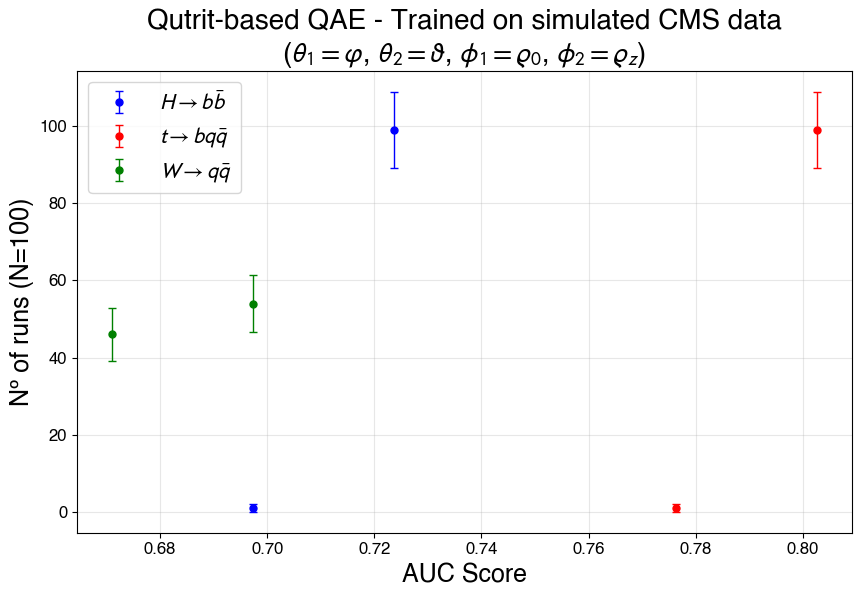

In [157]:
qutritsS1_d0dz_back_data  = qutritsd0dz_lt1['fil_100_back_S'].squeeze()
qutritsS1_d0dz_HToBB_data = qutritsd0dz_lt1['fil_100_HToBB_S'].squeeze()
qutritsS1_d0dz_WToQQ_data = qutritsd0dz_lt1['fil_100_WToQQ_S'].squeeze()
qutritsS1_d0dz_TTBar_data = qutritsd0dz_lt1['fil_100_TTBar_S'].squeeze()

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qutritsd0dz,
    'TTBar': auc_TTBar_list_qutritsd0dz,
    'WToQQ': auc_WToQQ_list_qutritsd0dz
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=18, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=18, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.grid(alpha=0.3)
plt.savefig(f"qutritsS_AUC.pdf", bbox_inches='tight')
plt.show()

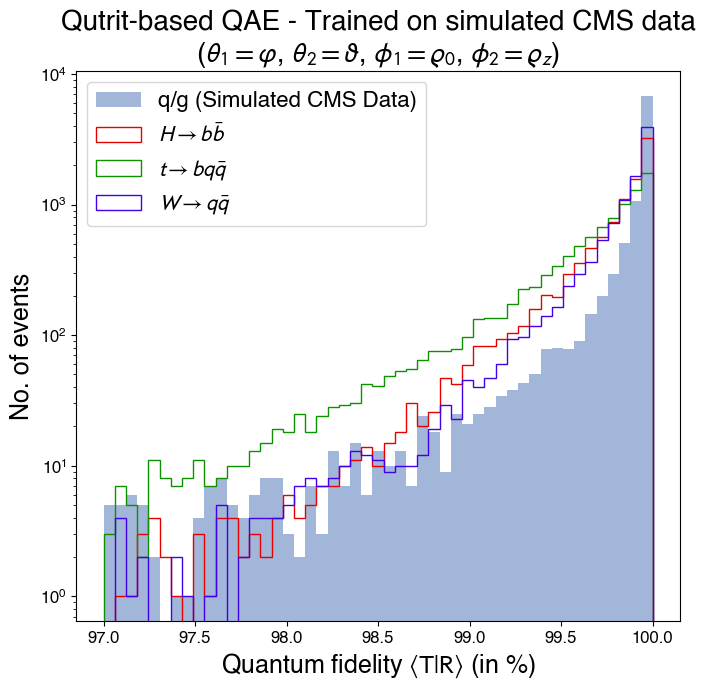

In [159]:
qutritsS1_d0dz_back_data  = qutritsd0dz_lt1['fil_100_back_S'].squeeze()
qutritsS1_d0dz_HToBB_data = qutritsd0dz_lt1['fil_100_HToBB_S'].squeeze()
qutritsS1_d0dz_WToQQ_data = qutritsd0dz_lt1['fil_100_WToQQ_S'].squeeze()
qutritsS1_d0dz_TTBar_data = qutritsd0dz_lt1['fil_100_TTBar_S'].squeeze()



plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsS1_d0dz_back_data[34].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g (Simulated CMS Data)')

#  H → bb : 
plt.hist(qutritsS1_d0dz_HToBB_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsS1_d0dz_TTBar_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsS1_d0dz_WToQQ_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=18)
plt.ylabel(r'No. of events', fontsize=18)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \varrho_0$, $\phi_2 = \varrho_z$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.tight_layout()
plt.savefig(f"qutritsS_97.pdf", bbox_inches='tight')
plt.show()

### **Analizamos BACK-BACK**

In [25]:
qutritsd0dz_back_data = qutritsd0dz_back['fil_100_back_S'].squeeze()
qutritsd0dz_back2_data = qutritsd0dz_back['fil_100_back2_S'].squeeze()

# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qubitsR_back_data.shape)
print(qubitsR_back2_data.shape)

W_back_mean, W_back_std, W_back_all = compute_wasserstein_runs(qutritsd0dz_back_data, qutritsd0dz_back2_data)

print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("Background vs Background", W_back_mean, W_back_std),
]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_back_list = []
jsd_back = []
fpr_back_list = []
tpr_back_list = []


for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutritsd0dz_back_data[i]
    pdf_back2 = qutritsd0dz_back2_data[i]
    # ---------- JS divergence ----------
    jsd_back.append(jensenshannon(pdf_back2, pdf_back))
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qutritsd0dz_back_data[i])
    anomaly_scores_back2 = 1 - np.array(qutritsd0dz_back2_data[i])


    y_true_back = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_back2)
    ])

    scores_back = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_back2
    ])

    fpr_back, tpr_back, _ = roc_curve(y_true_back, scores_back)
    auc_back = roc_auc_score(y_true_back, scores_back)

    auc_back_list.append(auc_back)
    fpr_back_list.append(fpr_back)
    tpr_back_list.append(tpr_back)

# =========================
mean_auc_back = np.mean(auc_back_list)
std_auc_back  = np.std(auc_back_list)

mean_jsd_back = np.mean(jsd_back)
std_jsd_back  = np.std(jsd_back)

print("=== AUC (mean ± std) ===")
print(f"Back  : {mean_auc_back:4f} ± {std_auc_back}")

print("=== JS distance (mean ± std) ===")
print(f"Back  : {mean_jsd_back:4f} ± {std_jsd_back}")


(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
Background vs Background  |     0.0638 ± 0.03450236190231286
-------------------------------------------------------
=== AUC (mean ± std) ===
Back  : 0.499145 ± 0.00422834437033359
=== JS distance (mean ± std) ===
Back  : 0.032101 ± 0.0010602167674843325


### **Qutrits-based** model trained on simulated CMS data and using $\tau_{12}$ and the jet's energy (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTau12E`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [160]:
qutrits_tau12E_lt1_back_data  = qutrits_tau12E_lt1['fil_100_back_S'].squeeze()
qutrits_tau12E_lt1_HToBB_data = qutrits_tau12E_lt1['fil_100_HToBB_S'].squeeze()
qutrits_tau12E_lt1_WToQQ_data = qutrits_tau12E_lt1['fil_100_WToQQ_S'].squeeze()
qutrits_tau12E_lt1_TTBar_data = qutrits_tau12E_lt1['fil_100_TTBar_S'].squeeze()

print(qutrits_tau12E_lt1_back_data.shape)
print(qutrits_tau12E_lt1_HToBB_data.shape)
print(qutrits_tau12E_lt1_WToQQ_data.shape)
print(qutrits_tau12E_lt1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [161]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutrits_tau12E_lt1_HToBB_data, qutrits_tau12E_lt1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutrits_tau12E_lt1_WToQQ_data, qutrits_tau12E_lt1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutrits_tau12E_lt1_TTBar_data, qutrits_tau12E_lt1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutrits_tau12E_lt1_HToBB_data, qutrits_tau12E_lt1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutrits_tau12E_lt1_HToBB_data, qutrits_tau12E_lt1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutrits_tau12E_lt1_WToQQ_data, qutrits_tau12E_lt1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8619 ± 0.043093719510673346
WToQQ (Boson W) vs Background |     0.3133 ± 0.04100847113352859
TTBar (Top) vs Background |     1.4511 ± 0.04278410573370753
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5624 ± 0.001122242510376632
HToBB (Higgs) vs TTBar (Top) |     0.5894 ± 0.0019531992957550546
WToQQ (Boson W) vs TTBar (Top) |     1.1516 ± 0.0023100976560184684
-------------------------------------------------------


In [162]:

# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTau12E = []
means_WToQQ_qutritsTau12E = []
means_TTBar_qutritsTau12E = []
means_back_qutritsTau12E = []

median_HToBB_qutritsTau12E = []
median_WToQQ_qutritsTau12E = []
median_TTBar_qutritsTau12E = []
median_back_qutritsTau12E = []

auc_HToBB_list_qutritsTau12E = []
auc_TTBar_list_qutritsTau12E = []
auc_WToQQ_list_qutritsTau12E = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutrits_tau12E_lt1_back_data[i]
    pdf_HToBB = qutrits_tau12E_lt1_HToBB_data[i]
    pdf_WToQQ = qutrits_tau12E_lt1_WToQQ_data[i]
    pdf_TTBar = qutrits_tau12E_lt1_TTBar_data[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    len_hb = min(len(pdf_HToBB), len(pdf_back))
    len_wb = min(len(pdf_WToQQ), len(pdf_back))
    len_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:len_hb], pdf_back[:len_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:len_wb], pdf_back[:len_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:len_tb], pdf_back[:len_tb]))

    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB, pdf_WToQQ))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB, pdf_TTBar))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ, pdf_TTBar))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back
    

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutrits_tau12E_lt1_back_data[i]
    anomaly_scores_HToBB = 1 - qutrits_tau12E_lt1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutrits_tau12E_lt1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutrits_tau12E_lt1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau12E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau12E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTau12E.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau12E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau12E):.4f} ± {np.std(auc_HToBB_list_qutritsTau12E)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTau12E):.4f} ± {np.std(auc_WToQQ_list_qutritsTau12E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau12E):.4f} ± {np.std(auc_TTBar_list_qutritsTau12E)}")


# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")


=== Resultados qutritsTau12E ===
AUC HToBB: 0.7563 ± 0.008573434472994794
AUC WToQQ: 0.7147 ± 0.008378327212935773
AUC TTBar: 0.8277 ± 0.0074253052817648425
=== JS distance (mean ± std) ===
HToBB  : 0.042349 ± 0.0005477256292529135
WToQQ  : 0.035308 ± 0.0006374219460254809
TTBar  : 0.045998 ± 0.0005533577027612952
----------------------------------------------------------
HToBB  : 0.044485 ± 5.144344183177286e-05
HToBB  : 0.053285 ± 5.9806379138300585e-05
WToQQ  : 0.048663 ± 5.6462209728477785e-05


In [100]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 986005
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.6005%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 972892
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.2892%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 981375
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.1375%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 960666
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    96.0666%
------------------------------


In [163]:


# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qutritsTau12E) + 
                   np.array(auc_WToQQ_list_qutritsTau12E) + 
                   np.array(auc_TTBar_list_qutritsTau12E)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qutritsTau12E[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qutritsTau12E[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qutritsTau12E[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 34) ===
AUC HToBB: 0.7654
AUC WToQQ: 0.7243
AUC TTBar: 0.8352


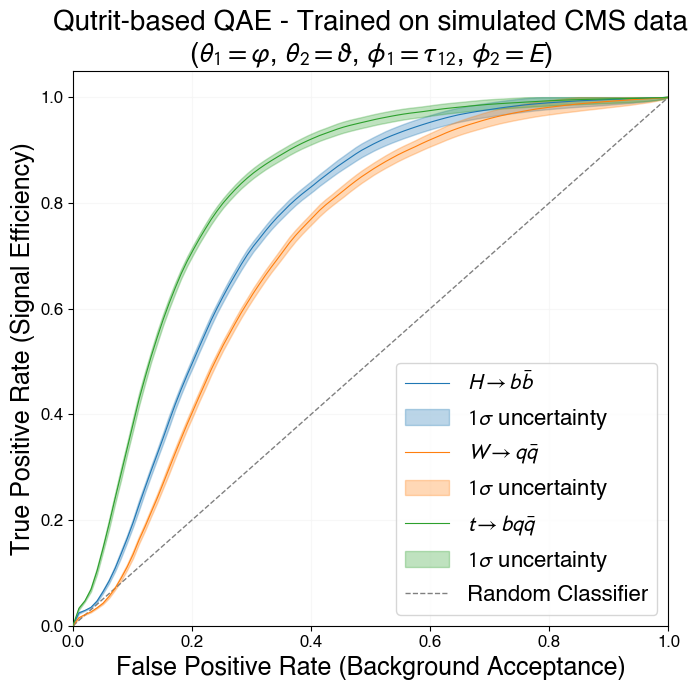

In [165]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=18, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=18, fontname="Helvetica")
ax.set_title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{12}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.savefig(f"qutritsS_12_ROC.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

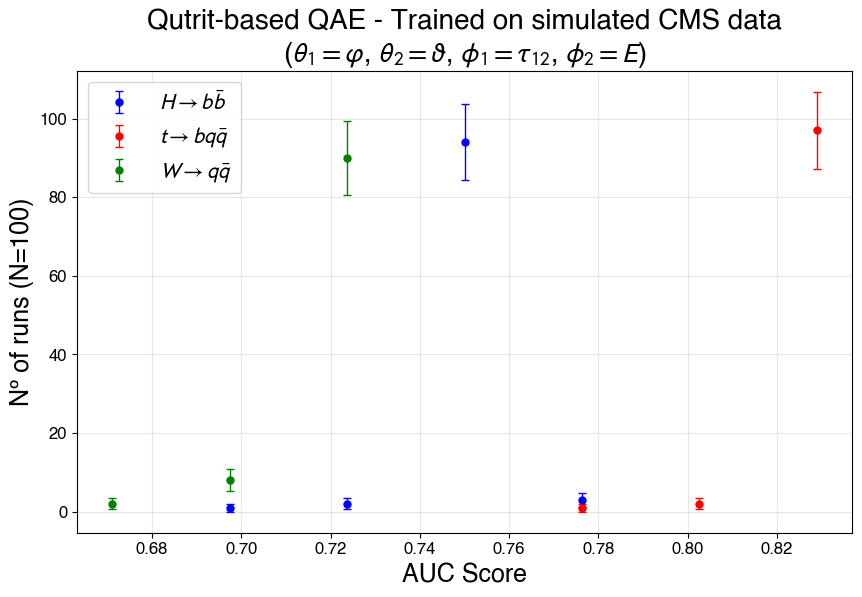

In [166]:

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qutritsTau12E,
    'TTBar': auc_TTBar_list_qutritsTau12E,
    'WToQQ': auc_WToQQ_list_qutritsTau12E
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{12}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=18, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=18, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.grid(alpha=0.3)
plt.savefig(f"qutritsS_12_AUC.pdf", bbox_inches='tight')
plt.show()

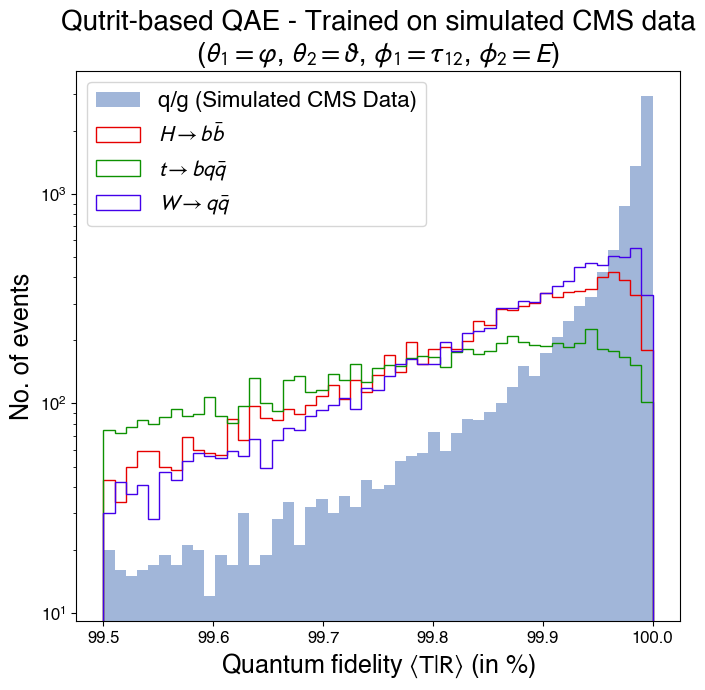

In [168]:
qutrits_tau12E_lt1_back_data  = qutrits_tau12E_lt1['fil_100_back_S'].squeeze()
qutrits_tau12E_lt1_HToBB_data = qutrits_tau12E_lt1['fil_100_HToBB_S'].squeeze()
qutrits_tau12E_lt1_WToQQ_data = qutrits_tau12E_lt1['fil_100_WToQQ_S'].squeeze()
qutrits_tau12E_lt1_TTBar_data = qutrits_tau12E_lt1['fil_100_TTBar_S'].squeeze()


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(99.5, 100, 50)

# Background: blue fill
plt.hist(qutrits_tau12E_lt1_back_data[34].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g (Simulated CMS Data)')

#  H → bb : 
plt.hist(qutrits_tau12E_lt1_HToBB_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutrits_tau12E_lt1_TTBar_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutrits_tau12E_lt1_WToQQ_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=18)
plt.ylabel(r'No. of events', fontsize=18)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{12}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.tight_layout()
plt.savefig(f"qutritsS_12_99.pdf", bbox_inches='tight')
plt.show()

### **Analizamos BACK-BACK**

In [24]:
qutrits_tau12E_back_data = qutrits_tau12E_back['fil_100_back_S'].squeeze()
qutrits_tau12E_back2_data = qutrits_tau12E_back['fil_100_back2_S'].squeeze()

# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutrits_tau12E_back_data.shape)
print(qutrits_tau12E_back2_data.shape)

W_back_mean, W_back_std, W_back_all = compute_wasserstein_runs(qutrits_tau12E_back_data, qutrits_tau12E_back2_data)

print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("Background vs Background", W_back_mean, W_back_std),
]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_back_list = []
jsd_back = []
fpr_back_list = []
tpr_back_list = []


for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutrits_tau12E_back_data[i]
    pdf_back2 = qutrits_tau12E_back2_data[i]
    # ---------- JS divergence ----------
    jsd_back.append(jensenshannon(pdf_back2, pdf_back))
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qutrits_tau12E_back_data[i])
    anomaly_scores_back2 = 1 - np.array(qutrits_tau12E_back2_data[i])


    y_true_back = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_back2)
    ])

    scores_back = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_back2
    ])

    fpr_back, tpr_back, _ = roc_curve(y_true_back, scores_back)
    auc_back = roc_auc_score(y_true_back, scores_back)

    auc_back_list.append(auc_back)
    fpr_back_list.append(fpr_back)
    tpr_back_list.append(tpr_back)

# =========================
mean_auc_back = np.mean(auc_back_list)
std_auc_back  = np.std(auc_back_list)

mean_jsd_back = np.mean(jsd_back)
std_jsd_back  = np.std(jsd_back)

print("=== AUC (mean ± std) ===")
print(f"Back  : {mean_auc_back:4f} ± {std_auc_back}")

print("=== JS distance (mean ± std) ===")
print(f"Back  : {mean_jsd_back:4f} ± {std_jsd_back}")


(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
Background vs Background  |     0.0635 ± 0.03447617709418976
-------------------------------------------------------
=== AUC (mean ± std) ===
Back  : 0.499442 ± 0.004451951746260897
=== JS distance (mean ± std) ===
Back  : 0.032069 ± 0.0010647957655151986


### **Qutrits-based** model trained on simulated CMS data and using $\tau_{23}$ and the jet's energy (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTau23E`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [169]:
qutritsTau23E_l1_back_data = qutrits_tau23E_lt1['fil_100_back_S'].squeeze()
qutritsTau23E_l1_HToBB_data = qutrits_tau23E_lt1['fil_100_HToBB_S'].squeeze()
qutritsTau23E_l1_WToQQ_data = qutrits_tau23E_lt1['fil_100_WToQQ_S'].squeeze()
qutritsTau23E_l1_TTBar_data = qutrits_tau23E_lt1['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsTau23E_l1_back_data.shape)
print(qutritsTau23E_l1_HToBB_data.shape)
print(qutritsTau23E_l1_WToQQ_data.shape)
print(qutritsTau23E_l1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [170]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsTau23E_l1_WToQQ_data, qutritsTau23E_l1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_TTBar_data, qutritsTau23E_l1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_WToQQ_data, qutritsTau23E_l1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8610 ± 0.04310419247949293
WToQQ (Boson W) vs Background |     0.3139 ± 0.041160136084215725
TTBar (Top) vs Background |     1.4511 ± 0.04296677767899099
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5616 ± 0.00107643437767647
HToBB (Higgs) vs TTBar (Top) |     0.5903 ± 0.001356836870800832
WToQQ (Boson W) vs TTBar (Top) |     1.1516 ± 0.0017947839581729011
-------------------------------------------------------


In [171]:

# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTau23E = []
means_WToQQ_qutritsTau23E = []
means_TTBar_qutritsTau23E = []
means_back_qutritsTau23E = []

median_HToBB_qutritsTau23E = []
median_WToQQ_qutritsTau23E = []
median_TTBar_qutritsTau23E = []
median_back_qutritsTau23E = []

auc_HToBB_list_qutritsTau23E = []
auc_TTBar_list_qutritsTau23E = []
auc_WToQQ_list_qutritsTau23E = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0
# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):
    
    # ---------- PDFs ----------
    pdf_back  = qutritsTau23E_l1_back_data[i]
    pdf_HToBB = qutritsTau23E_l1_HToBB_data[i]
    pdf_WToQQ = qutritsTau23E_l1_WToQQ_data[i]
    pdf_TTBar = qutritsTau23E_l1_TTBar_data[i]
    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTau23E_l1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsTau23E_l1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsTau23E_l1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsTau23E_l1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau23E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau23E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTau23E.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau23E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau23E):.4f} ± {np.std(auc_HToBB_list_qutritsTau23E)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTau23E):.4f} ± {np.std(auc_WToQQ_list_qutritsTau23E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau23E):.4f} ± {np.std(auc_TTBar_list_qutritsTau23E)}")


# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")

=== Resultados qutritsTau23E ===
AUC HToBB: 0.7564 ± 0.007974794561718424
AUC WToQQ: 0.7155 ± 0.008004796366080164
AUC TTBar: 0.8277 ± 0.006984065016180558
=== JS distance (mean ± std) ===
HToBB  : 0.042359 ± 0.0005446903866454258
WToQQ  : 0.035314 ± 0.0006354763901284092
TTBar  : 0.046003 ± 0.0005484946472315456
----------------------------------------------------------
HToBB  : 0.044493 ± 4.517671412284543e-05
HToBB  : 0.053295 ± 4.957588517253397e-05
WToQQ  : 0.048666 ± 4.5858609463394466e-05


In [172]:


# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qutritsTau23E) + 
                   np.array(auc_WToQQ_list_qutritsTau23E) + 
                   np.array(auc_TTBar_list_qutritsTau23E)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qutritsTau23E[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qutritsTau23E[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qutritsTau23E[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 94) ===
AUC HToBB: 0.7657
AUC WToQQ: 0.7254
AUC TTBar: 0.8356


In [34]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 985804
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.5804%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 972992
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.2992%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 981286
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.1286%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 960941
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    96.0941%
------------------------------


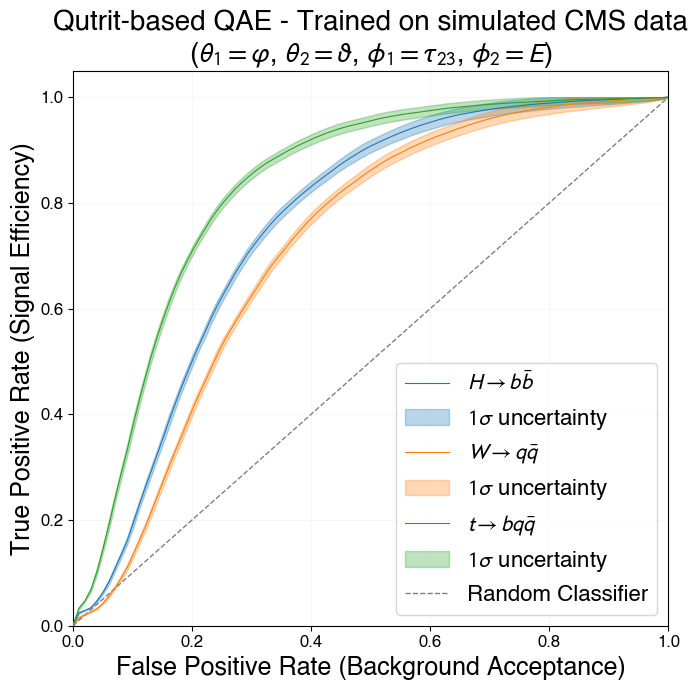

In [173]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=18, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=18, fontname="Helvetica")
ax.set_title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{23}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.savefig(f"qutritsS_23_ROC.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

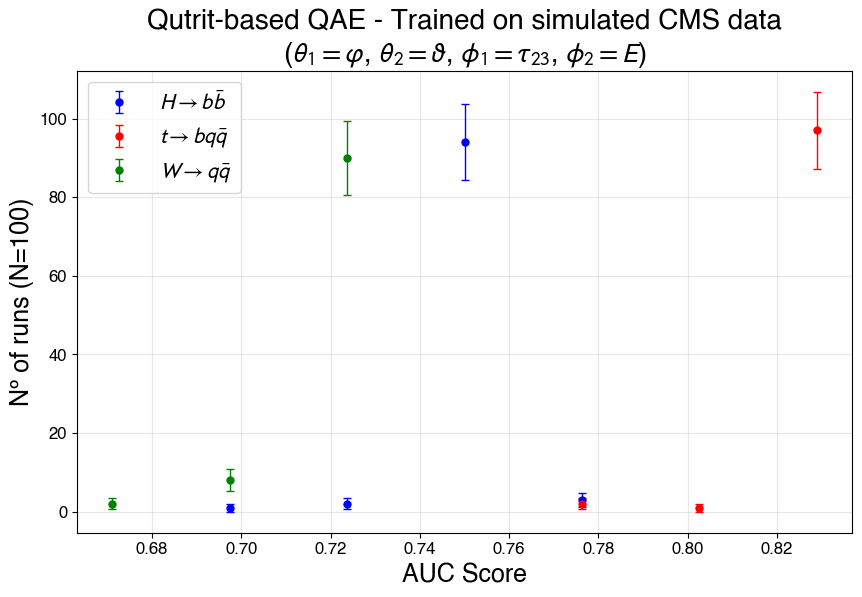

In [174]:

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qutritsTau23E,
    'TTBar': auc_TTBar_list_qutritsTau23E,
    'WToQQ': auc_WToQQ_list_qutritsTau23E
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{23}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=18, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=18, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.grid(alpha=0.3)
plt.savefig(f"qutritsS_23_AUC.pdf", bbox_inches='tight')
plt.show()

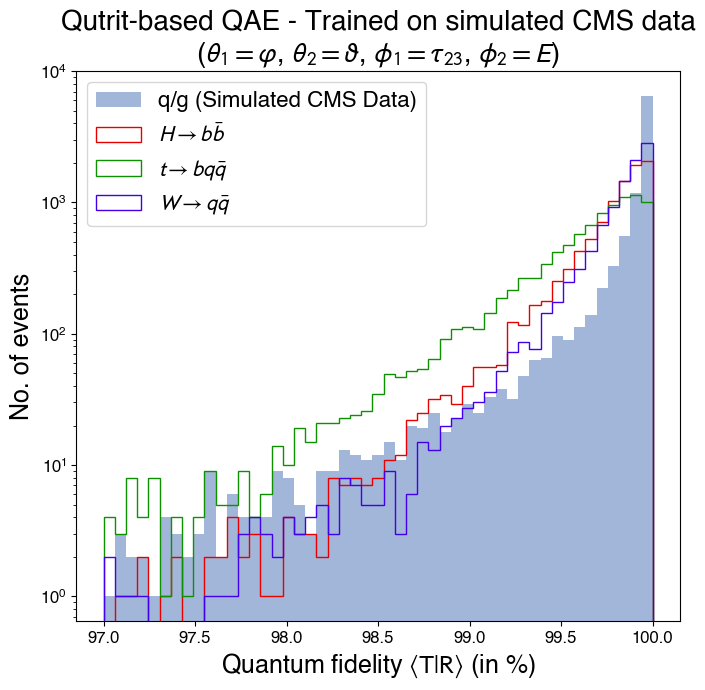

In [176]:
qutrits_tau23E_lt1_back_data  = qutrits_tau23E_lt1['fil_100_back_S'].squeeze()
qutrits_tau23E_lt1_HToBB_data = qutrits_tau23E_lt1['fil_100_HToBB_S'].squeeze()
qutrits_tau23E_lt1_WToQQ_data = qutrits_tau23E_lt1['fil_100_WToQQ_S'].squeeze()
qutrits_tau23E_lt1_TTBar_data = qutrits_tau23E_lt1['fil_100_TTBar_S'].squeeze()


plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutrits_tau23E_lt1_back_data[94].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g (Simulated CMS Data)')

#  H → bb : 
plt.hist(qutrits_tau23E_lt1_HToBB_data[94].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutrits_tau23E_lt1_TTBar_data[94].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutrits_tau23E_lt1_WToQQ_data[94].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=18)
plt.ylabel(r'No. of events', fontsize=18)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{23}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.tight_layout()
plt.savefig(f"qutritsS_23_97.pdf", bbox_inches='tight')
plt.show()

### **ANALIZAMOS BACK-BACK**

In [22]:
qutrits_tau23E_back_data = qutrits_tau23E_back['fil_100_back_S'].squeeze()
qutrits_tau23E_back2_data = qutrits_tau23E_back['fil_100_back2_S'].squeeze()

# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutrits_tau23E_back_data.shape)
print(qutrits_tau23E_back2_data.shape)

W_back_mean, W_back_std, W_back_all = compute_wasserstein_runs(qutrits_tau23E_back_data, qutrits_tau23E_back2_data)

print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("Background vs Background", W_back_mean, W_back_std),
]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_back_list = []
jsd_back = []
fpr_back_list = []
tpr_back_list = []


for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutrits_tau23E_back_data[i]
    pdf_back2 = qutrits_tau23E_back2_data[i]
    # ---------- JS divergence ----------
    jsd_back.append(jensenshannon(pdf_back2, pdf_back))
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qutrits_tau23E_back_data[i])
    anomaly_scores_back2 = 1 - np.array(qutrits_tau23E_back2_data[i])


    y_true_back = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_back2)
    ])

    scores_back = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_back2
    ])

    fpr_back, tpr_back, _ = roc_curve(y_true_back, scores_back)
    auc_back = roc_auc_score(y_true_back, scores_back)

    auc_back_list.append(auc_back)
    fpr_back_list.append(fpr_back)
    tpr_back_list.append(tpr_back)

# =========================
mean_auc_back = np.mean(auc_back_list)
std_auc_back  = np.std(auc_back_list)

mean_jsd_back = np.mean(jsd_back)
std_jsd_back  = np.std(jsd_back)

print("=== AUC (mean ± std) ===")
print(f"Back  : {mean_auc_back:4f} ± {std_auc_back}")

print("=== JS distance (mean ± std) ===")
print(f"Back  : {mean_jsd_back:4f} ± {std_jsd_back}")


(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
Background vs Background  |     0.0637 ± 0.034219218235061
-------------------------------------------------------
=== AUC (mean ± std) ===
Back  : 0.499483 ± 0.004404483872226511
=== JS distance (mean ± std) ===
Back  : 0.032069 ± 0.0010657432658000377


### **Qutrits-based** model using $\tau_{23}$ with a 3\% of random variation in $p_T$

In [47]:
qutritsTau23E_l1_back_data = qutrits_3_rand['fil_100_back_S'].squeeze()
qutritsTau23E_l1_HToBB_data = qutrits_3_rand['fil_100_HToBB_S'].squeeze()
qutritsTau23E_l1_TTBar_data = qutrits_3_rand['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsTau23E_l1_back_data.shape)
print(qutritsTau23E_l1_HToBB_data.shape)
print(qutritsTau23E_l1_TTBar_data.shape)

W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_TTBar_data, qutritsTau23E_l1_back_data)

W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_HToBB_list_qutritsTau23E = []
auc_TTBar_list_qutritsTau23E = []

jsd_HToBB_back = []
jsd_TTBar_back = []
jsd_HToBB_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []
fpr_TTBar_list = []
tpr_TTBar_list = []

for i in range(100):
    
    # ---------- PDFs ----------
    pdf_back  = qutritsTau23E_l1_back_data[i]
    pdf_HToBB = qutritsTau23E_l1_HToBB_data[i]
    pdf_TTBar = qutritsTau23E_l1_TTBar_data[i]
    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTau23E_l1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsTau23E_l1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsTau23E_l1_TTBar_data[i]


    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau23E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau23E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)


# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau23E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau23E):.4f} ± {np.std(auc_HToBB_list_qutritsTau23E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau23E):.4f} ± {np.std(auc_TTBar_list_qutritsTau23E)}")


# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)

print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")


CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8611 ± 0.04323830918532687
TTBar (Top) vs Background |     1.4513 ± 0.04298822036796509
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs TTBar (Top) |     0.5904 ± 0.001165135757941084
-------------------------------------------------------
=== Resultados qutritsTau23E ===
AUC HToBB: 0.7570 ± 0.0066845558579388805
AUC TTBar: 0.8283 ± 0.005284158123383227
=== JS distance (mean ± std) ===
HToBB  : 0.042361 ± 0.0005416334061035994
TTBar  : 0.046005 ± 0.0005454888742189354
----------------------------------------------------------
HToBB  : 0.044515 ± 6.22638743662358e-07
HToBB  : 0.053298 ± 4.0702609367075474e-05


### **Qutrits-based** model using $\tau_{23}$ with a  + 3\% of variation in $p_T$

In [48]:
qutritsTau23E_l1_back_data = qutrits_3_max['fil_100_back_S'].squeeze()
qutritsTau23E_l1_HToBB_data = qutrits_3_max['fil_100_HToBB_S'].squeeze()
qutritsTau23E_l1_TTBar_data = qutrits_3_max['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsTau23E_l1_back_data.shape)
print(qutritsTau23E_l1_HToBB_data.shape)
print(qutritsTau23E_l1_TTBar_data.shape)

W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_TTBar_data, qutritsTau23E_l1_back_data)

W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_HToBB_list_qutritsTau23E = []
auc_TTBar_list_qutritsTau23E = []

jsd_HToBB_back = []
jsd_TTBar_back = []
jsd_HToBB_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []
fpr_TTBar_list = []
tpr_TTBar_list = []

for i in range(100):
    
    # ---------- PDFs ----------
    pdf_back  = qutritsTau23E_l1_back_data[i]
    pdf_HToBB = qutritsTau23E_l1_HToBB_data[i]
    pdf_TTBar = qutritsTau23E_l1_TTBar_data[i]
    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTau23E_l1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsTau23E_l1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsTau23E_l1_TTBar_data[i]


    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau23E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau23E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)


# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau23E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau23E):.4f} ± {np.std(auc_HToBB_list_qutritsTau23E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau23E):.4f} ± {np.std(auc_TTBar_list_qutritsTau23E)}")


# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)

print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")

(100, 10000)
(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8611 ± 0.043237225830100534
TTBar (Top) vs Background |     1.4511 ± 0.04285588669627961
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs TTBar (Top) |     0.5903 ± 0.0021139015254410306
-------------------------------------------------------
=== Resultados qutritsTau23E ===
AUC HToBB: 0.7562 ± 0.008540948160594806
AUC TTBar: 0.8276 ± 0.007083916502702304
=== JS distance (mean ± std) ===
HToBB  : 0.042359 ± 0.0005460009090639311
TTBar  : 0.046002 ± 0.0005509255691286942
----------------------------------------------------------
HToBB  : 0.053295 ± 5.491562540823533e-05


### **Qutrits-based** model using $\tau_{23}$ with a  - 3\% of variation in $p_T$

In [49]:
qutritsTau23E_l1_back_data = qutrits_3_minus['fil_100_back_S'].squeeze()
qutritsTau23E_l1_HToBB_data = qutrits_3_minus['fil_100_HToBB_S'].squeeze()
qutritsTau23E_l1_TTBar_data = qutrits_3_minus['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsTau23E_l1_back_data.shape)
print(qutritsTau23E_l1_HToBB_data.shape)
print(qutritsTau23E_l1_TTBar_data.shape)

W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_TTBar_data, qutritsTau23E_l1_back_data)

W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsTau23E_l1_HToBB_data, qutritsTau23E_l1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_HToBB_list_qutritsTau23E = []
auc_TTBar_list_qutritsTau23E = []

jsd_HToBB_back = []
jsd_TTBar_back = []
jsd_HToBB_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []
fpr_TTBar_list = []
tpr_TTBar_list = []

for i in range(100):
    
    # ---------- PDFs ----------
    pdf_back  = qutritsTau23E_l1_back_data[i]
    pdf_HToBB = qutritsTau23E_l1_HToBB_data[i]
    pdf_TTBar = qutritsTau23E_l1_TTBar_data[i]
    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTau23E_l1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsTau23E_l1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsTau23E_l1_TTBar_data[i]


    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau23E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau23E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)


# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau23E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau23E):.4f} ± {np.std(auc_HToBB_list_qutritsTau23E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau23E):.4f} ± {np.std(auc_TTBar_list_qutritsTau23E)}")


# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)

print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")

(100, 10000)
(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8611 ± 0.04322429565265028
TTBar (Top) vs Background |     1.4512 ± 0.04304994171347941
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs TTBar (Top) |     0.5903 ± 0.0013053275167588582
-------------------------------------------------------
=== Resultados qutritsTau23E ===
AUC HToBB: 0.7568 ± 0.007336195150111588
AUC TTBar: 0.8280 ± 0.0065032599698897605
=== JS distance (mean ± std) ===
HToBB  : 0.042362 ± 0.0005413716741667473
TTBar  : 0.046005 ± 0.0005446594225261219
----------------------------------------------------------
HToBB  : 0.053298 ± 3.9107076653047255e-05


### **Qutrits-based** model trained on simulated CMS data and using $\tau_{34}$ and the jet's energy (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTau34E`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [178]:
qutritsTau34E_l1_back_data = qutrits_tau34E_lt1['fil_100_back_S'].squeeze()
qutritsTau34E_l1_HToBB_data = qutrits_tau34E_lt1['fil_100_HToBB_S'].squeeze()
qutritsTau34E_l1_WToQQ_data = qutrits_tau34E_lt1['fil_100_WToQQ_S'].squeeze()
qutritsTau34E_l1_TTBar_data = qutrits_tau34E_lt1['fil_100_TTBar_S'].squeeze()


# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutritsTau34E_l1_back_data.shape)
print(qutritsTau34E_l1_HToBB_data.shape)
print(qutritsTau34E_l1_WToQQ_data.shape)
print(qutritsTau34E_l1_TTBar_data.shape)

(100, 10000)
(100, 10000)
(100, 10000)
(100, 10000)


In [179]:
W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTau34E_l1_HToBB_data, qutritsTau34E_l1_back_data)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsTau34E_l1_WToQQ_data, qutritsTau34E_l1_back_data)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTau34E_l1_TTBar_data, qutritsTau34E_l1_back_data)

W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std, W_HToBB_WToQQ_all = compute_wasserstein_runs(qutritsTau34E_l1_HToBB_data, qutritsTau34E_l1_WToQQ_data)
W_HToBB_TTBar_mean, W_HToBB_TTBar_std, W_HToBB_TTBar_all = compute_wasserstein_runs(qutritsTau34E_l1_HToBB_data, qutritsTau34E_l1_TTBar_data)
W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std, W_WToQQ_TTBar_all = compute_wasserstein_runs(qutritsTau34E_l1_WToQQ_data, qutritsTau34E_l1_TTBar_data)


# Encabezado
print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("HToBB (Higgs) vs Background", W_HToBB_mean, W_HToBB_std),
    ("WToQQ (Boson W) vs Background", W_WToQQ_mean, W_WToQQ_std),
    ("TTBar (Top) vs Background",     W_TTBar_mean, W_TTBar_std),
    ("----------------------------------------------------------", 0, 0),
    ("HToBB (Higgs) vs WToQQ (Boson W)", W_HToBB_WToQQ_mean, W_HToBB_WToQQ_std),
    ("HToBB (Higgs) vs TTBar (Top)",     W_HToBB_TTBar_mean, W_HToBB_TTBar_std),
    ("WToQQ (Boson W) vs TTBar (Top)",   W_WToQQ_TTBar_mean, W_WToQQ_TTBar_std)

]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)



CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
HToBB (Higgs) vs Background |     0.8609 ± 0.04324984289496326
WToQQ (Boson W) vs Background |     0.3135 ± 0.04125231956675413
TTBar (Top) vs Background |     1.4504 ± 0.04289758754736518
---------------------------------------------------------- |     0.0000 ± 0
HToBB (Higgs) vs WToQQ (Boson W) |     0.5609 ± 0.0009024428681058144
HToBB (Higgs) vs TTBar (Top) |     0.5896 ± 0.0020965375435132777
WToQQ (Boson W) vs TTBar (Top) |     1.1502 ± 0.002257883850286503
-------------------------------------------------------


In [180]:

# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTau34E = []
means_WToQQ_qutritsTau34E = []
means_TTBar_qutritsTau34E = []
means_back_qutritsTau34E = []

median_HToBB_qutritsTau34E = []
median_WToQQ_qutritsTau34E = []
median_TTBar_qutritsTau34E = []
median_back_qutritsTau34E = []

auc_HToBB_list_qutritsTau34E = []
auc_TTBar_list_qutritsTau34E = []
auc_WToQQ_list_qutritsTau34E = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

acumulado_eventos_rango_HToBB = 0
acumulado_total_eventos_HToBB = 0

acumulado_eventos_rango_WToQQ = 0
acumulado_total_eventos_WToQQ = 0

acumulado_eventos_rango_TTBar = 0
acumulado_total_eventos_TTBar = 0

acumulado_eventos_rango_back  = 0
acumulado_total_eventos_back  = 0

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutritsTau34E_l1_back_data[i]
    pdf_HToBB = qutritsTau34E_l1_HToBB_data[i]
    pdf_WToQQ = qutritsTau34E_l1_WToQQ_data[i]
    pdf_TTBar = qutritsTau34E_l1_TTBar_data[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Numero de eventos en rango ----------
    mask_HToBB  = (pdf_HToBB >= 96.0) & (pdf_HToBB <= 100.0)
    eventos_en_rango_HToBB  = np.sum(mask_HToBB )
    total_iteracion_HToBB  = np.atleast_1d(pdf_HToBB).size
    acumulado_eventos_rango_HToBB += eventos_en_rango_HToBB
    acumulado_total_eventos_HToBB += total_iteracion_HToBB

    mask_WToQQ  = (pdf_WToQQ >= 96.0) & (pdf_WToQQ <= 100.0)
    eventos_en_rango_WToQQ  = np.sum(mask_WToQQ )
    total_iteracion_WToQQ  = np.atleast_1d(pdf_WToQQ).size
    acumulado_eventos_rango_WToQQ += eventos_en_rango_WToQQ
    acumulado_total_eventos_WToQQ += total_iteracion_WToQQ

    mask_TTBar  = (pdf_TTBar >= 96.0) & (pdf_TTBar <= 100.0)
    eventos_en_rango_TTBar  = np.sum(mask_TTBar )
    total_iteracion_TTBar  = np.atleast_1d(pdf_TTBar).size
    acumulado_eventos_rango_TTBar += eventos_en_rango_TTBar
    acumulado_total_eventos_TTBar += total_iteracion_TTBar

    mask_back  = (pdf_back >= 96.0) & (pdf_back <= 100.0)
    eventos_en_rango_back  = np.sum(mask_back )
    total_iteracion_back  = np.atleast_1d(pdf_back).size
    acumulado_eventos_rango_back += eventos_en_rango_back
    acumulado_total_eventos_back += total_iteracion_back

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTau34E_l1_back_data[i]
    anomaly_scores_HToBB = 1 - qutritsTau34E_l1_HToBB_data[i]
    anomaly_scores_TTBar = 1 - qutritsTau34E_l1_TTBar_data[i]
    anomaly_scores_WToQQ = 1 - qutritsTau34E_l1_WToQQ_data[i]

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTau34E.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTau34E.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTau34E.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

fraccion_global_back = acumulado_eventos_rango_back / acumulado_total_eventos_back
fraccion_global_HToBB = acumulado_eventos_rango_HToBB / acumulado_total_eventos_HToBB
fraccion_global_WToQQ = acumulado_eventos_rango_WToQQ / acumulado_total_eventos_WToQQ
fraccion_global_TTBar = acumulado_eventos_rango_TTBar / acumulado_total_eventos_TTBar

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTau34E ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTau34E):.4f} ± {np.std(auc_HToBB_list_qutritsTau34E)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTau34E):.4f} ± {np.std(auc_WToQQ_list_qutritsTau34E)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTau34E):.4f} ± {np.std(auc_TTBar_list_qutritsTau34E)}")


# =========================
# Promedios JS
# =========================

mean_jsd_HToBB_back = np.mean(jsd_HToBB_back)
std_jsd_HToBB_back  = np.std(jsd_HToBB_back)
mean_jsd_WToQQ_back = np.mean(jsd_WToQQ_back)
std_jsd_WToQQ_back  = np.std(jsd_WToQQ_back)
mean_jsd_TTBar_back = np.mean(jsd_TTBar_back)
std_jsd_TTBar_back  = np.std(jsd_TTBar_back)

mean_jsd_HToBB_WToQQ = np.mean(jsd_HToBB_WToQQ)
std_jsd_HToBB_WToQQ  = np.std(jsd_HToBB_WToQQ)
mean_jsd_HToBB_TTBar = np.mean(jsd_HToBB_TTBar)
std_jsd_HToBB_TTBar  = np.std(jsd_HToBB_TTBar)
mean_jsd_WToQQ_TTBar = np.mean(jsd_WToQQ_TTBar)
std_jsd_WToQQ_TTBar  = np.std(jsd_WToQQ_TTBar)


print("=== JS distance (mean ± std) ===")
print(f"HToBB  : {mean_jsd_HToBB_back:4f} ± {std_jsd_HToBB_back}")
print(f"WToQQ  : {mean_jsd_WToQQ_back:4f} ± {std_jsd_WToQQ_back}")
print(f"TTBar  : {mean_jsd_TTBar_back:4f} ± {std_jsd_TTBar_back}")   
print("----------------------------------------------------------")
print(f"HToBB  : {mean_jsd_HToBB_WToQQ:4f} ± {std_jsd_HToBB_WToQQ}")
print(f"HToBB  : {mean_jsd_HToBB_TTBar:4f} ± {std_jsd_HToBB_TTBar}")
print(f"WToQQ  : {mean_jsd_WToQQ_TTBar:4f} ± {std_jsd_WToQQ_TTBar}")


=== Resultados qutritsTau34E ===
AUC HToBB: 0.7564 ± 0.009438988897687229
AUC WToQQ: 0.7155 ± 0.009411235424729804
AUC TTBar: 0.8274 ± 0.008081233202288995
=== JS distance (mean ± std) ===
HToBB  : 0.042360 ± 0.0005477312877301663
WToQQ  : 0.035313 ± 0.0006373397995817175
TTBar  : 0.045997 ± 0.0005523861252496305
----------------------------------------------------------
HToBB  : 0.044492 ± 4.248920352856035e-05
HToBB  : 0.053296 ± 5.312301838854274e-05
WToQQ  : 0.048658 ± 5.021598049523364e-05


In [38]:
print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_back}")
print(f"Total eventos procesados:         {acumulado_total_eventos_back}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_back*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) HToBB")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_HToBB}")
print(f"Total eventos procesados:         {acumulado_total_eventos_HToBB}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_HToBB*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_WToQQ}")
print(f"Total eventos procesados:         {acumulado_total_eventos_WToQQ}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_WToQQ*100:.4f}%")
print("-" * 30)

print("-" * 30)
print(f"RESULTADOS ACUMULADOS (100 ejecuciones) TTBar")
print(f"Total eventos en rango (96-100%): {acumulado_eventos_rango_TTBar}")
print(f"Total eventos procesados:         {acumulado_total_eventos_TTBar}")
print(f"Fidelidad global (Eficiencia):    {fraccion_global_TTBar*100:.4f}%")
print("-" * 30)

------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) BACKGROUND
Total eventos en rango (96-100%): 985725
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.5725%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) HToBB
Total eventos en rango (96-100%): 973096
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    97.3096%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) WtoQQ
Total eventos en rango (96-100%): 981095
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    98.1095%
------------------------------
------------------------------
RESULTADOS ACUMULADOS (100 ejecuciones) TTBar
Total eventos en rango (96-100%): 960676
Total eventos procesados:         1000000
Fidelidad global (Eficiencia):    96.0676%
------------------------------


In [182]:


# Opción B (Recomendada): El índice que mejor promedio tiene de las tres señales
auc_avg_per_run = (np.array(auc_HToBB_list_qutritsTau34E) + 
                   np.array(auc_WToQQ_list_qutritsTau34E) + 
                   np.array(auc_TTBar_list_qutritsTau34E)) / 3
best_run_idx_avg = np.argmax(auc_avg_per_run)

print(f"\n=== MEJOR RUN (Índice {best_run_idx_avg}) ===")
print(f"AUC HToBB: {auc_HToBB_list_qutritsTau34E[best_run_idx_avg]:.4f}")
print(f"AUC WToQQ: {auc_WToQQ_list_qutritsTau34E[best_run_idx_avg]:.4f}")
print(f"AUC TTBar: {auc_TTBar_list_qutritsTau34E[best_run_idx_avg]:.4f}")


=== MEJOR RUN (Índice 34) ===
AUC HToBB: 0.7654
AUC WToQQ: 0.7251
AUC TTBar: 0.8346


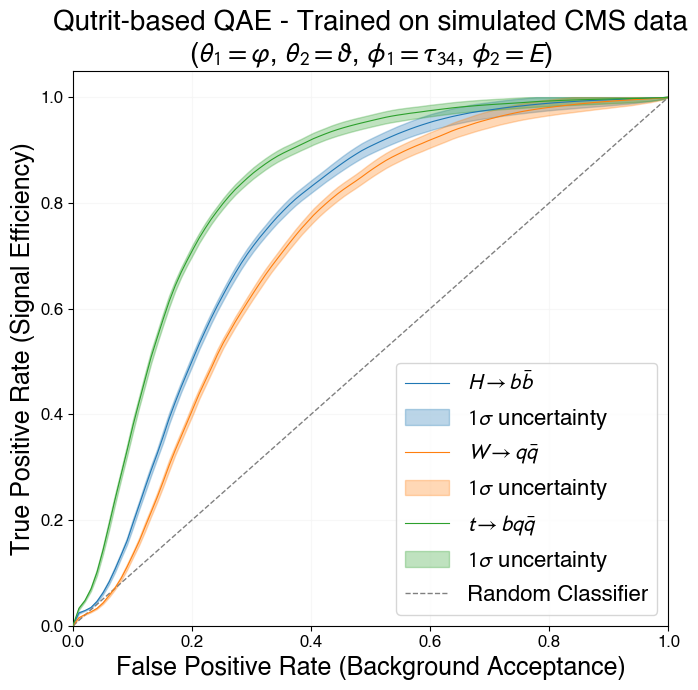

In [183]:
import matplotlib.pyplot as plt
import numpy as np

# ==========================================
# 1. CONFIGURACIÓN GLOBAL (HELVETICA)
# ==========================================
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')
common_fprs_linear = np.linspace(0, 1, 100)

# ==========================================
# 2. SECCIÓN DE CURVAS ROC (3 SEÑALES)
# ==========================================
# Grupo principal de las 3 señales solicitadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs_linear)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs_linear)

# ==========================================
# 3. SECCIÓN DE INCERTIDUMBRES Y REFERENCIAS
# ==========================================
# Aquí puedes añadir las bandas de error sistemático (JES) o estadístico
# como sombras (fill_between) o líneas de referencia adicionales
ax.plot([0, 1], [0, 1], color='grey', lw=1, ls='--', label='Random Classifier')

# Ejemplo de labels de incertidumbre agrupados (puedes descomentar y adaptar):
# ax.fill_between(common_fprs_linear, lower_bound, upper_bound, color='gray', alpha=0.2, label='Syst. Uncertainty (JES)')
# ax.plot(common_fprs_linear, statistical_err, color='black', lw=0.5, ls=':', label='Stat. Uncertainty (Std. Dev.)')

# ==========================================
# 4. AJUSTES VISUALES Y LABELS
# ==========================================
ax.set_xlim(0.0, 1.0) 
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("False Positive Rate (Background Acceptance)", fontsize=18, fontname="Helvetica")
ax.set_ylabel("True Positive Rate (Signal Efficiency)", fontsize=18, fontname="Helvetica")
ax.set_title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{34}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")

ax.grid(True, which="major", ls="-", color='whitesmoke', alpha=0.8)

# La leyenda organizará automáticamente los labels en el orden en que se graficaron
ax.legend(loc="lower right", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.savefig(f"qutritsS_34_ROC.pdf", bbox_inches='tight')
plt.tight_layout()
plt.show()

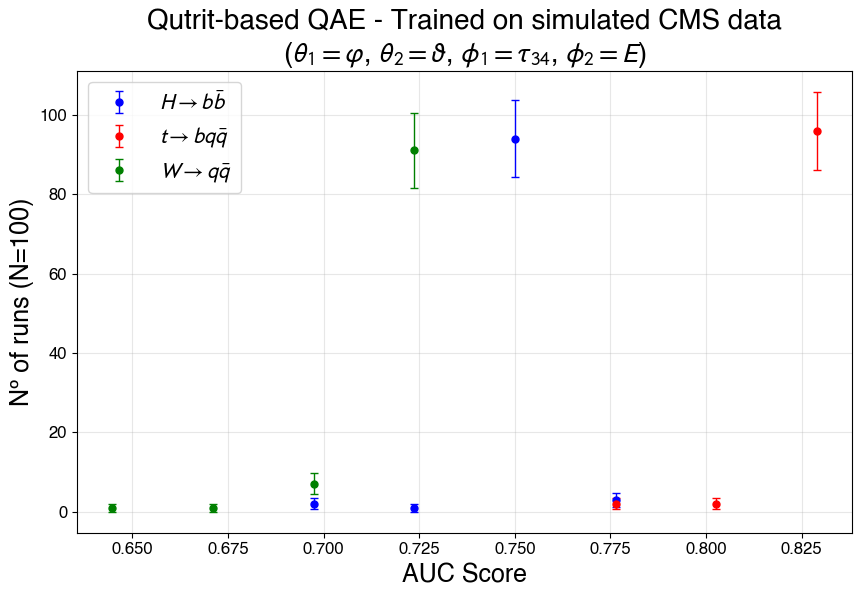

In [184]:

import matplotlib.pyplot as plt

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})
# Configuramos los datos a plotear
datasets = {
    'HToBB': auc_HToBB_list_qutritsTau34E,
    'TTBar': auc_TTBar_list_qutritsTau34E,
    'WToQQ': auc_WToQQ_list_qutritsTau34E
}

latex_labels = {
    'HToBB': r'$H \to b\bar{b}$',
    'TTBar': r'$t \to bq\bar{q}$',
    'WToQQ': r'$W \to q\bar{q}$'
}

colors = {
    'HToBB': 'blue',
    'TTBar': 'red',
    'WToQQ': 'green'
}

plt.figure(figsize=(10, 6))

# Definimos los bins (por ejemplo, 15 bins entre el mínimo y máximo AUC encontrado)
bins = np.linspace(0.5, 1.0, 20) # Ajusta el rango según tus resultados

for label, data in datasets.items():
    # 1. Calculamos el histograma (frecuencias)
    counts, bin_edges = np.histogram(data, bins=bins)
    
    # 2. Calculamos el centro de cada bin para posicionar el punto
    bin_centers = (bin_edges[:-1] + bin_edges[1:]) / 2
    
    # 3. La incertidumbre es la raíz cuadrada del número de eventos en cada bin
    errors = np.sqrt(counts)

    mask = counts > 0
    c_filtrados = counts[mask]
    bc_filtrados = bin_centers[mask]
    e_filtrados = errors[mask]
    
    # 4. Graficamos con barras de error
    # Usamos fmt='o' para puntos, capsize para las líneas horizontales del error
    plt.errorbar(bc_filtrados, c_filtrados, yerr=e_filtrados, fmt='o', 
                 label=f'{latex_labels[label]}', color=colors[label], 
                 markersize=5, capsize=3, elinewidth=1)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{34}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.xlabel('AUC Score', fontsize=18, fontname="Helvetica")
plt.ylabel('Nº of runs (N=100)', fontsize=18, fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.grid(alpha=0.3)
plt.savefig(f"qutritsS_34_AUC.pdf", bbox_inches='tight')
plt.show()

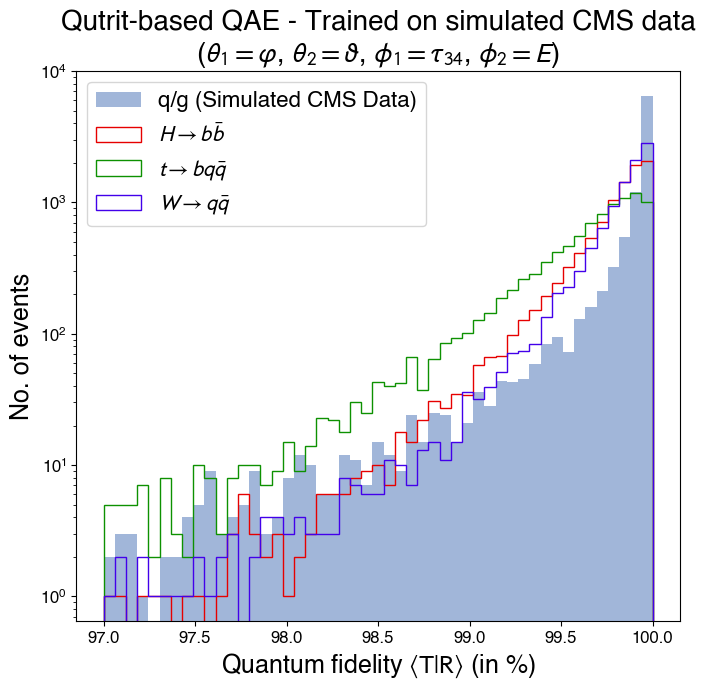

In [186]:
qutritsTau34E_l1_back_data = qutrits_tau34E_lt1['fil_100_back_S'].squeeze()
qutritsTau34E_l1_HToBB_data = qutrits_tau34E_lt1['fil_100_HToBB_S'].squeeze()
qutritsTau34E_l1_WToQQ_data = qutrits_tau34E_lt1['fil_100_WToQQ_S'].squeeze()
qutritsTau34E_l1_TTBar_data = qutrits_tau34E_lt1['fil_100_TTBar_S'].squeeze()

plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica", "Arial", "DejaVu Sans"],
    "text.usetex": False,
    "mathtext.fontset": "stixsans",
    
    # Aumentar el tamaño de los números en los ejes
    "xtick.labelsize": 12,
    "ytick.labelsize": 12,
})

fig, ax = plt.subplots(figsize=(7, 7), facecolor='white')

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsTau34E_l1_back_data[34].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g (Simulated CMS Data)')

#  H → bb : 
plt.hist(qutritsTau34E_l1_HToBB_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsTau34E_l1_TTBar_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsTau34E_l1_WToQQ_data[34].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle \text{T}|\text{R} \rangle$ (in %)', fontsize=18)
plt.ylabel(r'No. of events', fontsize=18)

plt.title(r"Qutrit-based QAE - Trained on simulated CMS data" "\n" r"($\theta_1 = \varphi$, $\theta_2 = \vartheta$, $\phi_1 = \tau_{34}$, $\phi_2 = E$)", fontsize=20, fontweight='bold', fontname="Helvetica")
plt.legend(loc="upper left", frameon=True, facecolor='white', prop={'family': 'Helvetica', 'size': 16})
plt.tight_layout()
plt.savefig(f"qutritsS_34_97.pdf", bbox_inches='tight')
plt.show()

## **Analizamos BACK-BACK**

In [23]:
qutrits_tau34E_back_data = qutrits_tau34E_back['fil_100_back_S'].squeeze()
qutrits_tau34E_back2_data = qutrits_tau34E_back['fil_100_back2_S'].squeeze()

# Ahora 'qubitsReal_data' es un array de NumPy normal
print(qutrits_tau34E_back_data.shape)
print(qutrits_tau34E_back2_data.shape)

W_back_mean, W_back_std, W_back_all = compute_wasserstein_runs(qutrits_tau34E_back_data, qutrits_tau34E_back2_data)

print(f"\n{'CANAL (vs Background)':<25} | {'DISTANCIA WASSERSTEIN':<25}")
print("-" * 55)
# Lista de resultados para iterar
wasserstein_results = [
    ("Background vs Background", W_back_mean, W_back_std),
]
# Impresión de filas
for nombre, mean, std in wasserstein_results:
    print(f"{nombre:<25} | {mean:>10.4f} ± {std}")
print("-" * 55)

auc_back_list = []
jsd_back = []
fpr_back_list = []
tpr_back_list = []


for i in range(100):

    # ---------- PDFs ----------
    pdf_back  = qutrits_tau34E_back_data[i]
    pdf_back2 = qutrits_tau34E_back2_data[i]
    # ---------- JS divergence ----------
    jsd_back.append(jensenshannon(pdf_back2, pdf_back))
    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - np.array(qutrits_tau34E_back_data[i])
    anomaly_scores_back2 = 1 - np.array(qutrits_tau34E_back2_data[i])


    y_true_back = np.concatenate([
        np.zeros_like(anomaly_scores_back),
        np.ones_like(anomaly_scores_back2)
    ])

    scores_back = np.concatenate([
        anomaly_scores_back,
        anomaly_scores_back2
    ])

    fpr_back, tpr_back, _ = roc_curve(y_true_back, scores_back)
    auc_back = roc_auc_score(y_true_back, scores_back)

    auc_back_list.append(auc_back)
    fpr_back_list.append(fpr_back)
    tpr_back_list.append(tpr_back)

# =========================
mean_auc_back = np.mean(auc_back_list)
std_auc_back  = np.std(auc_back_list)

mean_jsd_back = np.mean(jsd_back)
std_jsd_back  = np.std(jsd_back)

print("=== AUC (mean ± std) ===")
print(f"Back  : {mean_auc_back:4f} ± {std_auc_back}")

print("=== JS distance (mean ± std) ===")
print(f"Back  : {mean_jsd_back:4f} ± {std_jsd_back}")


(100, 10000)
(100, 10000)

CANAL (vs Background)     | DISTANCIA WASSERSTEIN    
-------------------------------------------------------
Background vs Background  |     0.0638 ± 0.034241190218980824
-------------------------------------------------------
=== AUC (mean ± std) ===
Back  : 0.499480 ± 0.004440712381101279
=== JS distance (mean ± std) ===
Back  : 0.032069 ± 0.0010655942199318657


### **Qutrits-based** model trained on simulated CMS data and using $\tau_{1}$, $\tau_{2}$, $\tau_{3}$ and $\tau_{4}$ (results)

This code performs statistical analysis and anomaly detection on datasets labeled `HToBB`, `WToQQ`, `TTBar`, and `back` from `qutritsTaus`.  

For each of 100 iterations, it computes:  
- **Mean and median** of each dataset.  
- **Jensen-Shannon divergence (JSD)** between signals and background, and between signal datasets.  
- **Anomaly scores** as `1 - probability` for each dataset.  
- **ROC AUC** to evaluate how well anomaly scores separate each signal from background.  

Finally, it calculates the **average AUC** and **average JSD** across all iterations to summarize overall separability and similarity.


In [23]:
# =========================
# Inicialización listas
# =========================

means_HToBB_qutritsTaus = []
means_WToQQ_qutritsTaus = []
means_TTBar_qutritsTaus = []
means_back_qutritsTaus = []

median_HToBB_qutritsTaus = []
median_WToQQ_qutritsTaus = []
median_TTBar_qutritsTaus = []
median_back_qutritsTaus = []

auc_HToBB_list_qutritsTaus = []
auc_TTBar_list_qutritsTaus = []
auc_WToQQ_list_qutritsTaus = []

jsd_HToBB_back = []
jsd_WToQQ_back = []
jsd_TTBar_back = []

jsd_HToBB_WToQQ = []
jsd_HToBB_TTBar = []
jsd_WToQQ_TTBar = []

# ROC storage
fpr_HToBB_list = []
tpr_HToBB_list = []

fpr_TTBar_list = []
tpr_TTBar_list = []

fpr_WToQQ_list = []
tpr_WToQQ_list = []

# =========================
# Datos (Adaptados a qutritsTaus)
# =========================

qutritsTaus_back  = qutritsTaus['fil_100_back_S'].squeeze()
qutritsTaus_HToBB = qutritsTaus['fil_100_HToBB_S'].squeeze()
qutritsTaus_WToQQ = qutritsTaus['fil_100_WToQQ_S'].squeeze()
qutritsTaus_TTBar = qutritsTaus['fil_100_TTBar_S'].squeeze()

# =========================
# Loop sobre ejecuciones
# =========================

for i in range(100):

    # ---------- Stats ----------
    means_back_qutritsTaus.append(np.mean(qutritsTaus_back[i]))
    means_HToBB_qutritsTaus.append(np.mean(qutritsTaus_HToBB[i]))
    means_WToQQ_qutritsTaus.append(np.mean(qutritsTaus_WToQQ[i]))
    means_TTBar_qutritsTaus.append(np.mean(qutritsTaus_TTBar[i]))

    median_back_qutritsTaus.append(np.median(qutritsTaus_back[i]))
    median_HToBB_qutritsTaus.append(np.median(qutritsTaus_HToBB[i]))
    median_WToQQ_qutritsTaus.append(np.median(qutritsTaus_WToQQ[i]))
    median_TTBar_qutritsTaus.append(np.median(qutritsTaus_TTBar[i]))

    # ---------- PDFs ----------
    pdf_back  = qutritsTaus_back[i]
    pdf_HToBB = qutritsTaus_HToBB[i]
    pdf_WToQQ = qutritsTaus_WToQQ[i]
    pdf_TTBar = qutritsTaus_TTBar[i]

    # ---------- JS divergence (Con recorte dinámico) ----------
    
    # Pares contra Background
    l_hb = min(len(pdf_HToBB), len(pdf_back))
    l_wb = min(len(pdf_WToQQ), len(pdf_back))
    l_tb = min(len(pdf_TTBar), len(pdf_back))
    
    jsd_HToBB_back.append(jensenshannon(pdf_HToBB[:l_hb], pdf_back[:l_hb]))
    jsd_WToQQ_back.append(jensenshannon(pdf_WToQQ[:l_wb], pdf_back[:l_wb]))
    jsd_TTBar_back.append(jensenshannon(pdf_TTBar[:l_tb], pdf_back[:l_tb]))

    # Pares entre Señales
    l_hw = min(len(pdf_HToBB), len(pdf_WToQQ))
    l_ht = min(len(pdf_HToBB), len(pdf_TTBar))
    l_wt = min(len(pdf_WToQQ), len(pdf_TTBar))
    
    jsd_HToBB_WToQQ.append(jensenshannon(pdf_HToBB[:l_hw], pdf_WToQQ[:l_hw]))
    jsd_HToBB_TTBar.append(jensenshannon(pdf_HToBB[:l_ht], pdf_TTBar[:l_ht]))
    jsd_WToQQ_TTBar.append(jensenshannon(pdf_WToQQ[:l_wt], pdf_TTBar[:l_wt]))

    # ---------- Anomaly scores ----------
    anomaly_scores_back  = 1 - qutritsTaus_back[i].ravel()
    anomaly_scores_HToBB = 1 - qutritsTaus_HToBB[i].ravel()
    anomaly_scores_TTBar = 1 - qutritsTaus_TTBar[i].ravel()
    anomaly_scores_WToQQ = 1 - qutritsTaus_WToQQ[i].ravel()

    # =========================
    # HToBB ROC
    # =========================
    y_true_HToBB = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)])
    scores_HToBB = np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
    
    fpr_HToBB, tpr_HToBB, _ = roc_curve(y_true_HToBB, scores_HToBB)
    auc_HToBB = roc_auc_score(y_true_HToBB, scores_HToBB)
    
    auc_HToBB_list_qutritsTaus.append(auc_HToBB)
    fpr_HToBB_list.append(fpr_HToBB)
    tpr_HToBB_list.append(tpr_HToBB)

    # =========================
    # TTBar ROC
    # =========================
    y_true_TTBar = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)])
    scores_TTBar = np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
    
    fpr_TTBar, tpr_TTBar, _ = roc_curve(y_true_TTBar, scores_TTBar)
    auc_TTBar = roc_auc_score(y_true_TTBar, scores_TTBar)
    
    auc_TTBar_list_qutritsTaus.append(auc_TTBar)
    fpr_TTBar_list.append(fpr_TTBar)
    tpr_TTBar_list.append(tpr_TTBar)

    # =========================
    # WToQQ ROC
    # =========================
    y_true_WToQQ = np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)])
    scores_WToQQ = np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
    
    fpr_WToQQ, tpr_WToQQ, _ = roc_curve(y_true_WToQQ, scores_WToQQ)
    auc_WToQQ = roc_auc_score(y_true_WToQQ, scores_WToQQ)
    
    auc_WToQQ_list_qutritsTaus.append(auc_WToQQ)
    fpr_WToQQ_list.append(fpr_WToQQ)
    tpr_WToQQ_list.append(tpr_WToQQ)

# =========================
# Resultados Finales
# =========================

print(f"=== Resultados qutritsTaus ===")
print(f"AUC HToBB: {np.mean(auc_HToBB_list_qutritsTaus):.4f} ± {np.std(auc_HToBB_list_qutritsTaus)}")
print(f"AUC WToQQ: {np.mean(auc_WToQQ_list_qutritsTaus):.4f} ± {np.std(auc_WToQQ_list_qutritsTaus)}")
print(f"AUC TTBar: {np.mean(auc_TTBar_list_qutritsTaus):.4f} ± {np.std(auc_TTBar_list_qutritsTaus)}")

print("\n=== JS Distance (Promedio) ===")
print(f"JSD HToBB-Back: {np.mean(jsd_HToBB_back):.4f} ± {np.std(jsd_HToBB_back)}")
print(f"JSD WToQQ-Back: {np.mean(jsd_WToQQ_back):.4f} ± {np.std(jsd_WToQQ_back)}")
print(f"JSD TTBar-Back: {np.mean(jsd_TTBar_back):.4f} ± {np.std(jsd_TTBar_back)}")

=== Resultados qutritsTaus ===
AUC HToBB: 0.6871 ± 0.0018208562755617846
AUC WToQQ: 0.6334 ± 0.0010184908294326716
AUC TTBar: 0.8669 ± 0.0009995703486640828

=== JS Distance (Promedio) ===
JSD HToBB-Back: 0.0042 ± 1.7519867175307178e-05
JSD WToQQ-Back: 0.0043 ± 1.696803432439284e-05
JSD TTBar-Back: 0.0059 ± 1.6490104232286227e-05


In [ ]:
qutritsTaus_back = qutritsTaus['fil_100_back_S']
qutritsTaus_HToBB = qutritsTaus['fil_100_HToBB_S']
qutritsTaus_WToQQ = qutritsTaus['fil_100_WToQQ_S']
qutritsTaus_TTBar = qutritsTaus['fil_100_TTBar_S']  

qutritsTaus_back = qutritsTaus_back.squeeze()
qutritsTaus_HToBB = qutritsTaus_HToBB.squeeze()
qutritsTaus_WToQQ = qutritsTaus_WToQQ.squeeze()
qutritsTaus_TTBar = qutritsTaus_TTBar.squeeze()

W_HToBB_mean, W_HToBB_std, W_HToBB_all = compute_wasserstein_runs(qutritsTaus_HToBB, qutritsTaus_back)
W_WToQQ_mean, W_WToQQ_std, W_WToQQ_all = compute_wasserstein_runs(qutritsTaus_WToQQ, qutritsTaus_back)
W_TTBar_mean, W_TTBar_std, W_TTBar_all = compute_wasserstein_runs(qutritsTaus_TTBar, qutritsTaus_back)
print("=== Wasserstein Distance (mean ± std) ===")
print(f"HToBB  : {W_HToBB_mean:.4f} ± {W_HToBB_std}")
print(f"WToQQ  : {W_WToQQ_mean:.4f} ± {W_WToQQ_std}")
print(f"TTBar  : {W_TTBar_mean:.4f} ± {W_TTBar_std}")

=== Wasserstein Distance (mean ± std) ===
HToBB  : 0.2591 ± 0.005993441968763302
WToQQ  : 0.1862 ± 0.0030275880323208273
TTBar  : 1.1484 ± 0.01717613512169138


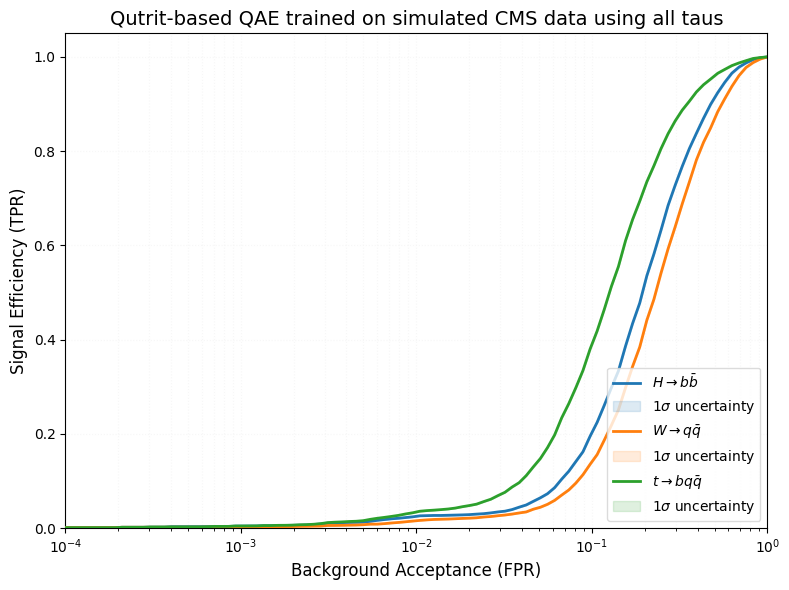

In [23]:
common_fprs = np.logspace(-4, 0, 100)

# 2. Creamos la figura con FONDO BLANCO
fig, ax = plt.subplots(figsize=(8, 6), facecolor='white')
ax.set_facecolor('white')

# 3. Añadimos cada señal con un color diferente
# Nota: Aquí pasas tus listas de FPR/TPR que ya tienes calculadas
add_performance_curve(ax, fpr_HToBB_list, tpr_HToBB_list, 
                      label=r"$H \to b\bar{b}$", color="tab:blue", target_fprs=common_fprs)

add_performance_curve(ax, fpr_WToQQ_list, tpr_WToQQ_list, 
                      label=r"$W \to q\bar{q}$", color="tab:orange", target_fprs=common_fprs)

add_performance_curve(ax, fpr_TTBar_list, tpr_TTBar_list, 
                      label=r"$t\to bq\bar{q}$", color="tab:green", target_fprs=common_fprs)

# 4. Ajustes visuales para que quede impecable (Sin líneas verticales en los bordes)
ax.set_xscale("log")
ax.set_xlim(common_fprs.min(), 1.0) # Corta justo donde empiezan los datos
ax.set_ylim(0.0, 1.05)

ax.set_xlabel("Background Acceptance (FPR)", fontsize=12)
ax.set_ylabel("Signal Efficiency (TPR)", fontsize=12)
ax.set_title(r"Qutrit-based QAE trained on simulated CMS data using all taus", fontsize=14)

# Grid muy sutil (casi invisible) para mantener el fondo blanco
ax.grid(True, which="both", ls=":", color='whitesmoke', alpha=0.8)

# Leyenda con fondo blanco
ax.legend(loc="lower right", frameon=True, facecolor='white', edgecolor='lightgrey')

plt.tight_layout()
plt.show()

### **Some prints to saw the result of previus calculations**

In [ ]:

print("----- Mean AUC Results -----")
print("--------------------------------")
print("----------QUBITS REAL-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qubitsReal)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qubitsReal)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qubitsReal)
print("----------QUTRITS REAL-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsReal)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsReal)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsReal)
print("--------------------------------")
print("--------SIMULATED DATA----------")
print("----------QUBITS-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qubits)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qubits)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qubits)
print("----------QUTRITS D0DZ-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsd0dz)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsd0dz)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsd0dz)
print("----------QUTRITS TAU12E-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTau12E)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTau12E)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTau12E)
print("----------QUTRITS TAU23E-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTau23E)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTau23E)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTau23E)
print("----------QUTRITS TAU34E-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTau34E)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTau34E)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTau34E)
print("----------QUTRITS ALL TAUS-------------")
print("Mean AUC HToBB: ", mean_auc_HToBB_qutritsTaus)
print("Mean AUC  TTBar: ", mean_auc_TTBar_qutritsTaus)
print("Mean AUC  WToQQ: ", mean_auc_WToQQ_qutritsTaus)

----- Mean AUC Results -----
--------------------------------
----------QUBITS REAL-------------
Mean AUC HToBB:  0.6687823041555001
Mean AUC  TTBar:  0.7661036927505002
Mean AUC  WToQQ:  0.6219458159259998
----------QUTRITS REAL-------------
Mean AUC HToBB:  0.7136422438519996
Mean AUC  TTBar:  0.7927688938940003
Mean AUC  WToQQ:  0.671160632956
--------------------------------
--------SIMULATED DATA----------
----------QUBITS-------------
Mean AUC HToBB:  0.775168388676603
Mean AUC  TTBar:  0.845749885190557
Mean AUC  WToQQ:  0.7333995047039111
----------QUTRITS D0DZ-------------
Mean AUC HToBB:  0.7312929073160003
Mean AUC  TTBar:  0.8099593322309999
Mean AUC  WToQQ:  0.6880127092720001
----------QUTRITS TAU12E-------------
Mean AUC HToBB:  0.7626888172579999
Mean AUC  TTBar:  0.8329333438459997
Mean AUC  WToQQ:  0.7216948242079998
----------QUTRITS TAU23E-------------
Mean AUC HToBB:  0.7634379140569999
Mean AUC  TTBar:  0.8335271029619997
Mean AUC  WToQQ:  0.7231186645800001
-----

---
---

---
---

# **SOME PLOTS** (ROC Curves, Fidelitiy distributions...)

AUC (QCD vs H→bb): 0.7761
AUC (QCD vs t→bqq): 0.8570
AUC (QCD vs W→qq): 0.7308


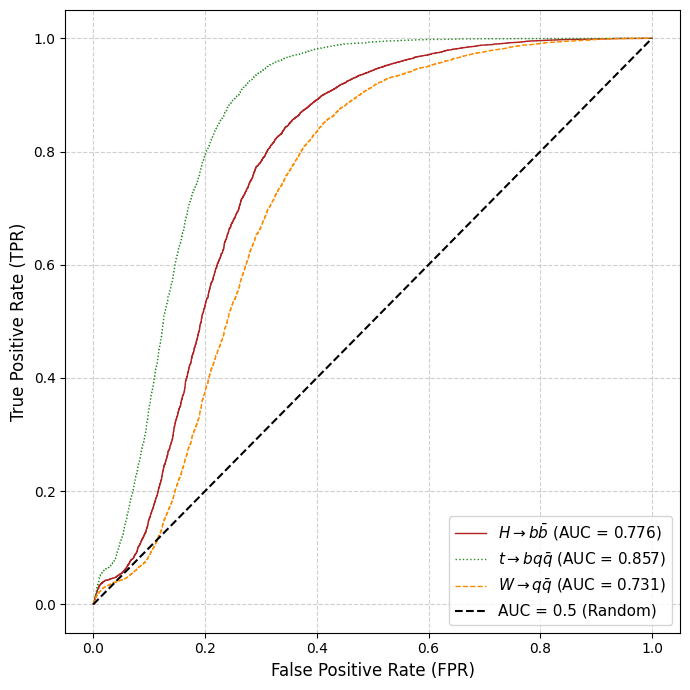

-------------------------------------------
KL Divergence (Qubits Real Fidelity)
-------------------------------------
HToBB || TTBar:  nan
TTBar || HToBB:  nan
WToQQ || HToBB: 0.022620665506836078
HToBB || WToQQ: 0.0221304162737243
WToQQ || TTBar: nan
TTBar || WToQQ: nan


/Users/mcarou/Documents/PhD/Proyecto/Research-Intership-Memory/python_env/lib/python3.9/site-packages/numpy/lib/histograms.py:885: RuntimeWarning: invalid value encountered in divide
  return n/db/n.sum(), bin_edges


In [ ]:
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import numpy as np

qubits10 = np.load('./Qubits10.npz', allow_pickle=True)
qubits10_back = qubits10['fil_100_back_S']
qubits10_HToBB = qubits10['fil_100_HToBB_S']
qubits10_WToQQ = qubits10['fil_100_WToQQ_S']
qubits10_TTBar = qubits10['fil_100_TTBar_S']
qubits10_back = qubits10_back.squeeze()
qubits10_HToBB = qubits10_HToBB.squeeze()
qubits10_WToQQ = qubits10_WToQQ.squeeze()
qubits10_TTBar = qubits10_TTBar.squeeze()
# --- Anomaly scores (1 - Fidelity) ---
anomaly_scores_back = 1 - np.array(qubits10_back)
anomaly_scores_HToBB = 1 - np.array(qubits10_HToBB)
anomaly_scores_TTBar = 1 - np.array(qubits10_TTBar)
anomaly_scores_WToQQ = 1 - np.array(qubits10_WToQQ)

# --- Calcular AUC ---
auc_HToBB = roc_auc_score(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
)

auc_TTBar = roc_auc_score(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
)

auc_WToQQ = roc_auc_score(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
)

print(f"AUC (QCD vs H→bb): {auc_HToBB:.4f}")
print(f"AUC (QCD vs t→bqq): {auc_TTBar:.4f}")
print(f"AUC (QCD vs W→qq): {auc_WToQQ:.4f}")

# --- Graficar curvas ROC ---
plt.figure(figsize=(7, 7))

# H→bb
fpr_HToBB, tpr_HToBB, _ = roc_curve(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_HToBB)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_HToBB])
)
plt.plot(fpr_HToBB, tpr_HToBB, color='firebrick', linewidth=1,
         label=rf'$H \rightarrow b\bar{{b}}$ (AUC = {auc_HToBB:.3f})')

# t→bqq
fpr_TTBar, tpr_TTBar, _ = roc_curve(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_TTBar)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_TTBar])
)
plt.plot(fpr_TTBar, tpr_TTBar, color='forestgreen', linewidth=1, linestyle=':',
         label=rf'$t \rightarrow bq\bar{{q}}$ (AUC = {auc_TTBar:.3f})')

# W→qq
fpr_WToQQ, tpr_WToQQ, _ = roc_curve(
    np.concatenate([np.zeros_like(anomaly_scores_back), np.ones_like(anomaly_scores_WToQQ)]),
    np.concatenate([anomaly_scores_back, anomaly_scores_WToQQ])
)
plt.plot(fpr_WToQQ, tpr_WToQQ, color='darkorange', linewidth=1, linestyle='--',
         label=rf'$W \rightarrow q\bar{{q}}$ (AUC = {auc_WToQQ:.3f})')

# Línea aleatoria (AUC = 0.5)
plt.plot([0, 1], [0, 1], 'k--', label=r'AUC = 0.5 (Random)')

# --- Personalización ejes y leyenda ---
plt.xlabel(r'False Positive Rate (FPR)', fontsize=12)
plt.ylabel(r'True Positive Rate (TPR)', fontsize=12)
#plt.title(r'ROC Curve ', fontsize=12, pad=5)
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.6)

# Ajuste márgenes y guardado
plt.tight_layout()
plt.savefig("metricas_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

import numpy as np
from scipy.stats import entropy   # implementa KL divergence

def kl_divergence(p_samples, q_samples, bins=50):

    p_hist, bin_edges = np.histogram(p_samples, bins=bins, density=True)
    q_hist, _ = np.histogram(q_samples, bins=bin_edges, density=True)

    # evitar ceros (KL no está definida)
    p_hist += 1e-10
    q_hist += 1e-10

    return entropy(p_hist, q_hist)   # KL(p||q)

print("-------------------------------------------")
print("KL Divergence (Qubits Real Fidelity)")
print("-------------------------------------")

print("HToBB || TTBar: ", kl_divergence(qubits10_HToBB, anomaly_scores_TTBar))
print("TTBar || HToBB: ", kl_divergence(anomaly_scores_TTBar, qubits10_HToBB))

print("WToQQ || HToBB:", kl_divergence(qubits10_WToQQ, qubits10_HToBB))
print("HToBB || WToQQ:", kl_divergence(qubits10_HToBB, qubits10_WToQQ))

print("WToQQ || TTBar:", kl_divergence(qubits10_WToQQ, anomaly_scores_TTBar))
print("TTBar || WToQQ:", kl_divergence(anomaly_scores_TTBar, qubits10_WToQQ))

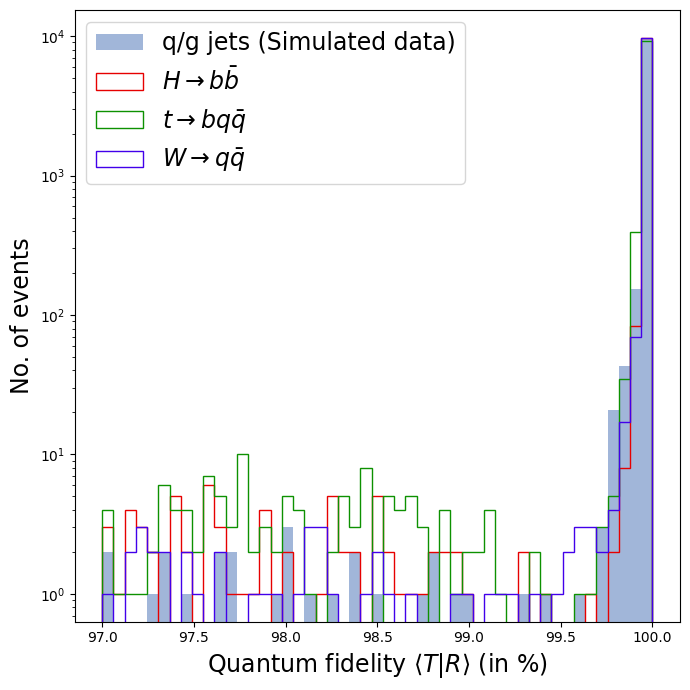

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qubits_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qubits_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qubits_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qubits_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

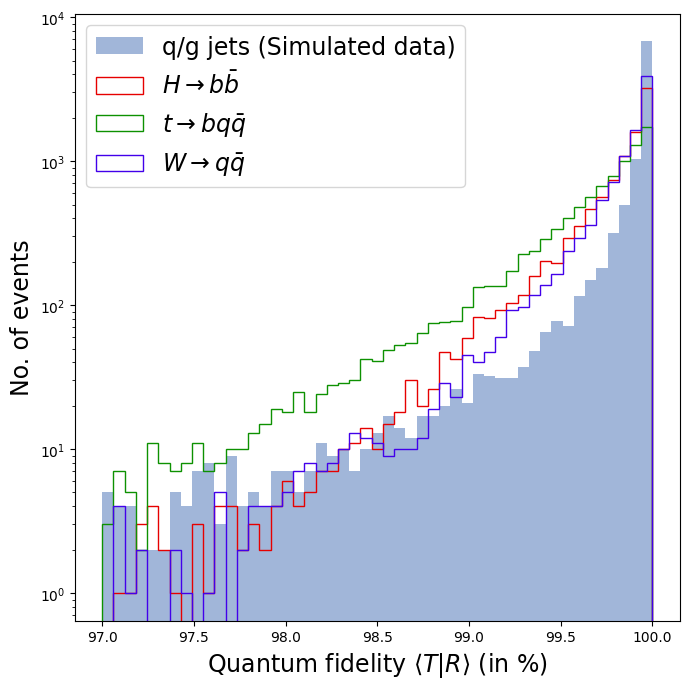

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsd0dz_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsd0dz_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsd0dz_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsd0dz_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

qutritsTau12E_back = qutritsTau12E_back.squeeze()
qutritsTau12E_HToBB = qutritsTau12E_HToBB.squeeze()
qutritsTau12E_WToQQ = qutritsTau12E_WToQQ.squeeze()
qutritsTau12E_TTBar = qutritsTau12E_TTBar.squeeze()

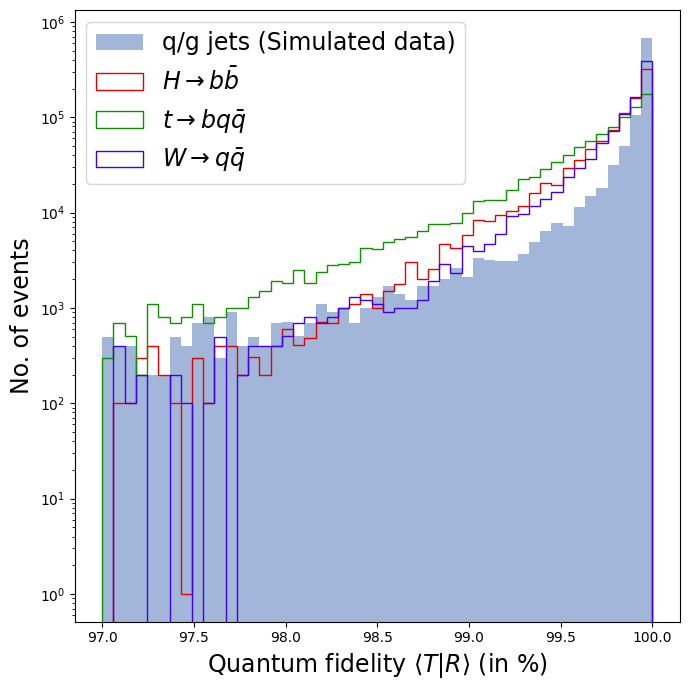

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsd0dz_back.flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsd0dz_HToBB.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsd0dz_TTBar.flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsd0dz_WToQQ.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

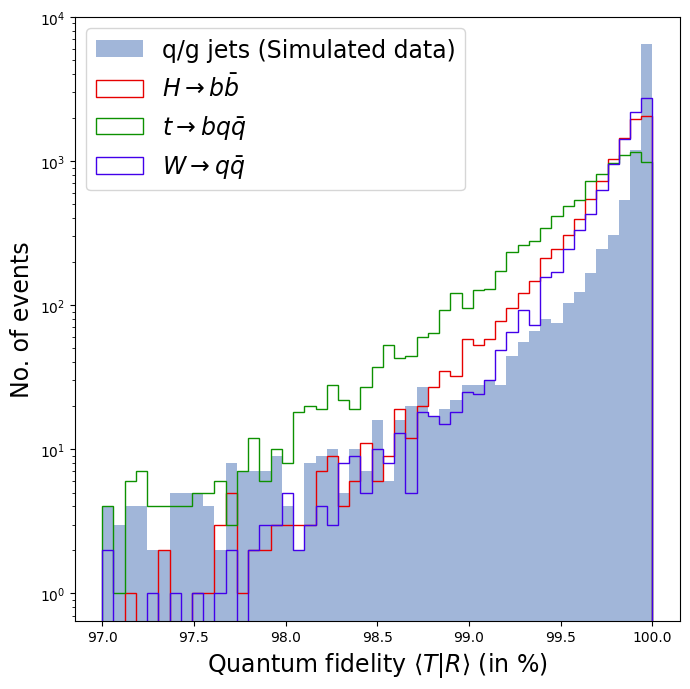

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsTau12E_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsTau12E_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsTau12E_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsTau12E_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

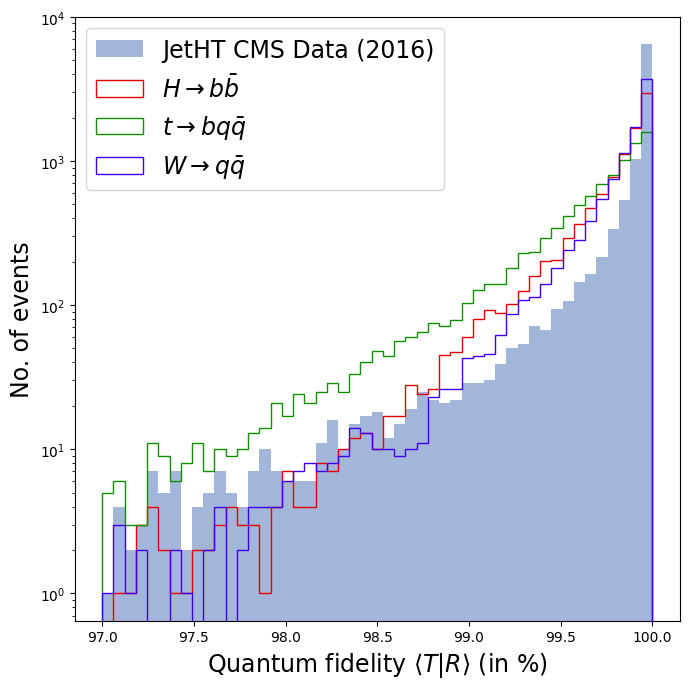

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsReal_back[-1].flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'JetHT CMS Data (2016)')

#  H → bb : 
plt.hist(qutritsReal_HToBB[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsReal_TTBar[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsReal_WToQQ[-1].flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

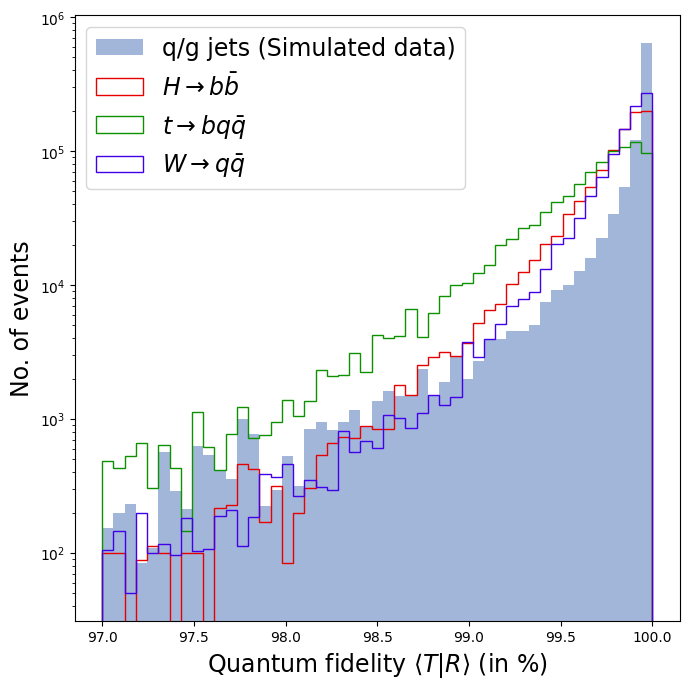

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Defining bins (from 97 to 100, as in the reference)
bins = np.linspace(97, 100, 50)

# Background: blue fill
plt.hist(qutritsTau34E_back.flatten(), 
         bins=bins, 
         histtype='stepfilled', 
         color="#7998CAB6", 
         alpha=0.7, 
         log=True,
         label=r'q/g jets (Simulated data)')

#  H → bb : 
plt.hist(qutritsTau34E_HToBB.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#E60000", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$H \rightarrow b\bar{b}$')

# t → bqq :
plt.hist(qutritsTau34E_TTBar.flatten(), 
         bins=bins, 
         histtype='step', 
         color='#0D9101', 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$t \rightarrow bq\bar{q}$')

#  W → qq : 
plt.hist(qutritsTau34E_WToQQ.flatten(), 
         bins=bins, 
         histtype='step', 
         color="#4200EA", 
         linewidth=1, 
         linestyle='-', 
         log=True,
         label=r'$W \rightarrow q\bar{q}$')


plt.yscale('log')
plt.xlabel(r'Quantum fidelity $\langle T|R \rangle$ (in %)', fontsize=17)
plt.ylabel(r'No. of events', fontsize=17)
#plt.title(r'QAE trained on JetHT CMS Data (2016)', fontsize=12, pad=5)
plt.legend(loc='upper left', fontsize=17)
plt.tight_layout()
#plt.savefig("test_rots2.png", dpi=300, bbox_inches='tight')
plt.show()

## **Dispersion Analysis**

From this point onward, we will analyze how dispersed the results are among the different datasets results. 
This helps to understand the variability and consistency of the computed metrics.


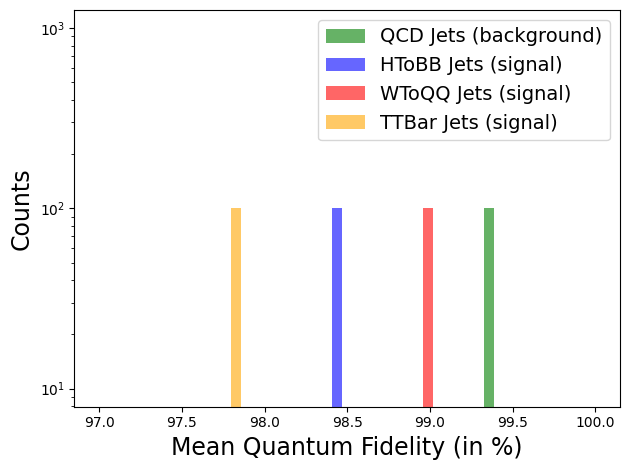

In [ ]:
bins = np.linspace(97, 100, 50)
plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.6, color='b', label='HToBB Jets (signal)', log=True)
plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.6, color='r', label='WToQQ Jets (signal)', log=True)
plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.6, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

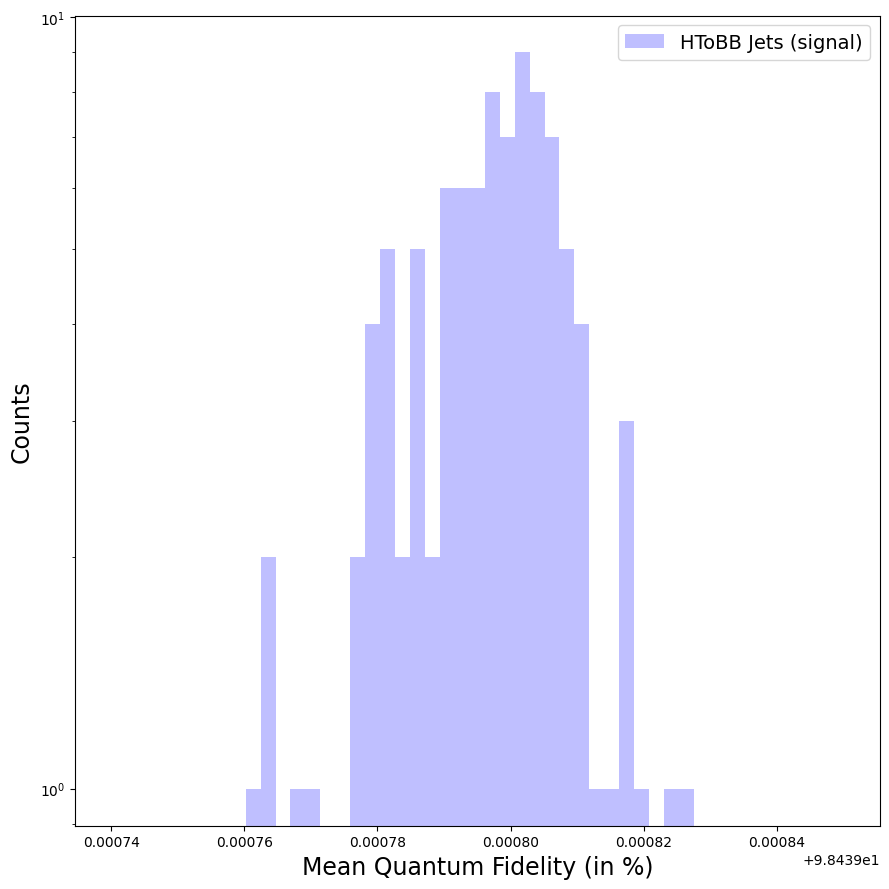

In [ ]:
plt.figure(figsize=(9, 9))
bins = np.linspace(98.43974, 98.43985, 50)
#plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.25, color='b', label='HToBB Jets (signal)', log=True)
#plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.6, color='r', label='WToQQ Jets (signal)', log=True)
#plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.6, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

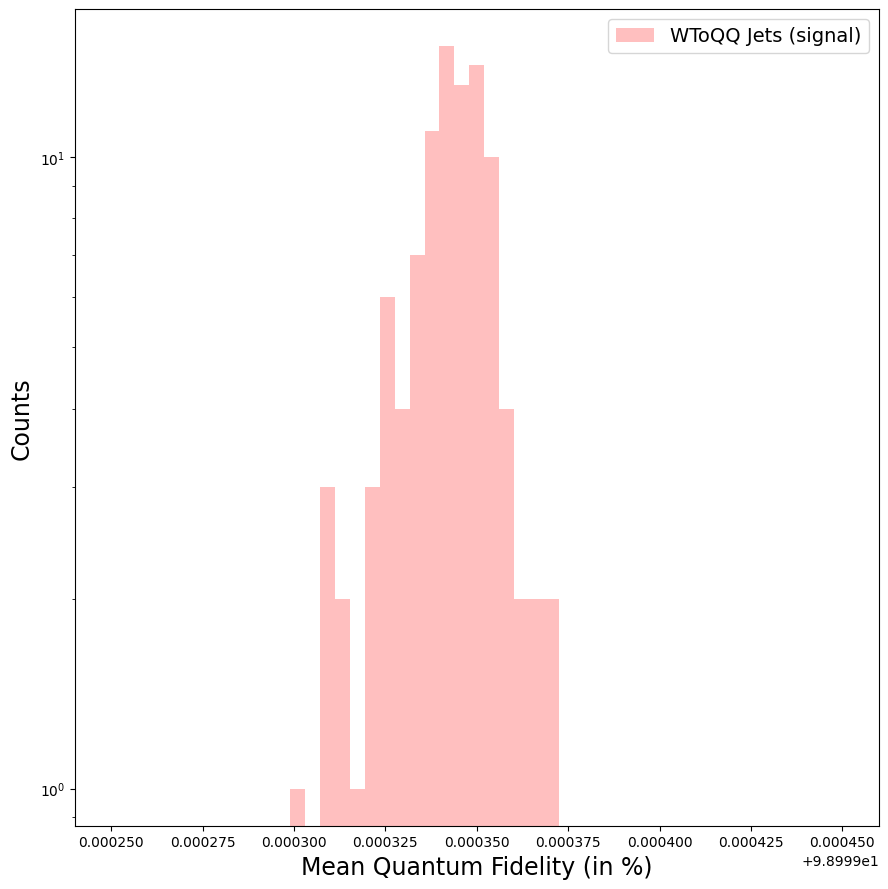

In [ ]:
plt.figure(figsize=(9, 9))
bins = np.linspace(98.99925, 98.99945, 50)
#plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
#plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.6, color='b', label='HToBB Jets (signal)', log=True)
plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.25, color='r', label='WToQQ Jets (signal)', log=True)
#plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.6, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()

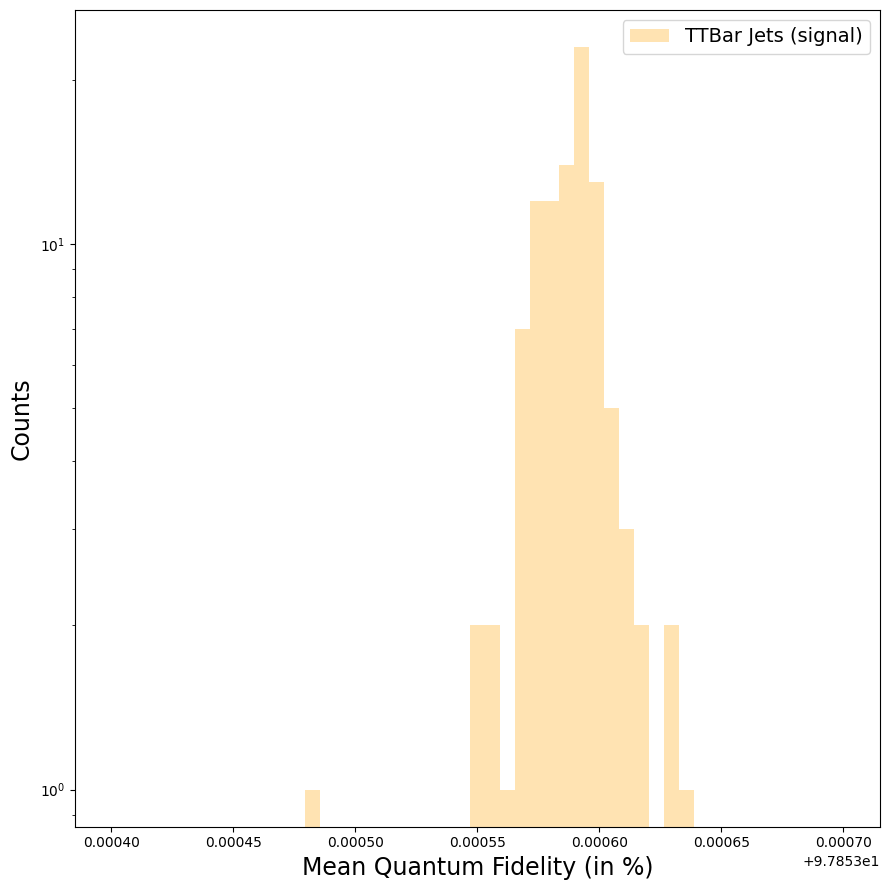

In [ ]:
plt.figure(figsize=(9, 9))
bins = np.linspace(97.8534, 97.8537, 50)
#plt.hist(means_back_qutritsd0dz, bins=bins,  alpha=0.6, color='g', label='QCD Jets (background)', log=True)
#plt.hist(means_HToBB_qutritsd0dz, bins=bins,  alpha=0.6, color='b', label='HToBB Jets (signal)', log=True)
#plt.hist(means_WToQQ_qutritsd0dz, bins=bins,  alpha=0.6, color='r', label='WToQQ Jets (signal)', log=True)
plt.hist(means_TTBar_qutritsd0dz, bins=bins,  alpha=0.3, color='orange', label='TTBar Jets (signal)', log=True)
plt.xlabel('Mean Quantum Fidelity (in %)', fontsize=17)
plt.ylabel('Counts', fontsize=17)
plt.legend(fontsize=14)
plt.tight_layout()
plt.show()